In [ ]:
!rm -rf /content/classification_dataset

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="aj5WTd95g8x6St9A79Su")
project = rf.workspace("my-model").project("student-attention-tracking")
version = project.version(2)
dataset = version.download("yolov8")


DEPRECATION: Loading egg at c:\users\sadneya\appdata\local\programs\python\python312\lib\site-packages\vboxapi-1.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Student-Attention-Tracking-2 in yolov8:: 100%|██████████| 2882/2882 [00:03<00:00, 916.49it/s] 


DOWNLOADING DATASET IN CORRECT FORMAT

METHOD 1: TRYING FOLDER FORMAT
loading Roboflow workspace...
loading Roboflow project...

❌ Folder format failed: {
    "error": "folder is an invalid format for project type object-detection. Please use one of: clip, coco, coco-mmdetection, createml, darknet, multiclass, tensorflow, tfrecord, voc, yolokeras, yolov4pytorch, yolov4scaled, yolov5-obb, yolov5pytorch, yolov7pytorch, yolov8, yolov8-obb, yolov9, yolov11, yolov12, mt-yolov6, retinanet, benchmarker, paligemma, paligemma-txt, florence2-od, openai."
}

METHOD 2: CONVERTING YOLOV8 TO CLASSIFICATION
loading Roboflow workspace...
loading Roboflow project...

📋 Classes: ['Attentive', 'Daydreaming', 'Distracted', 'Hand Rising', 'Phone Use', 'Sleepy']

🔄 Converting train...
  Attentive: 202 images
  Daydreaming: 9 images
  Distracted: 206 images
  Hand Rising: 110 images
  Phone Use: 140 images
  Sleepy: 221 images

🔄 Converting valid...
  Attentive: 12 images
  Daydreaming: 1 images
  Distracted

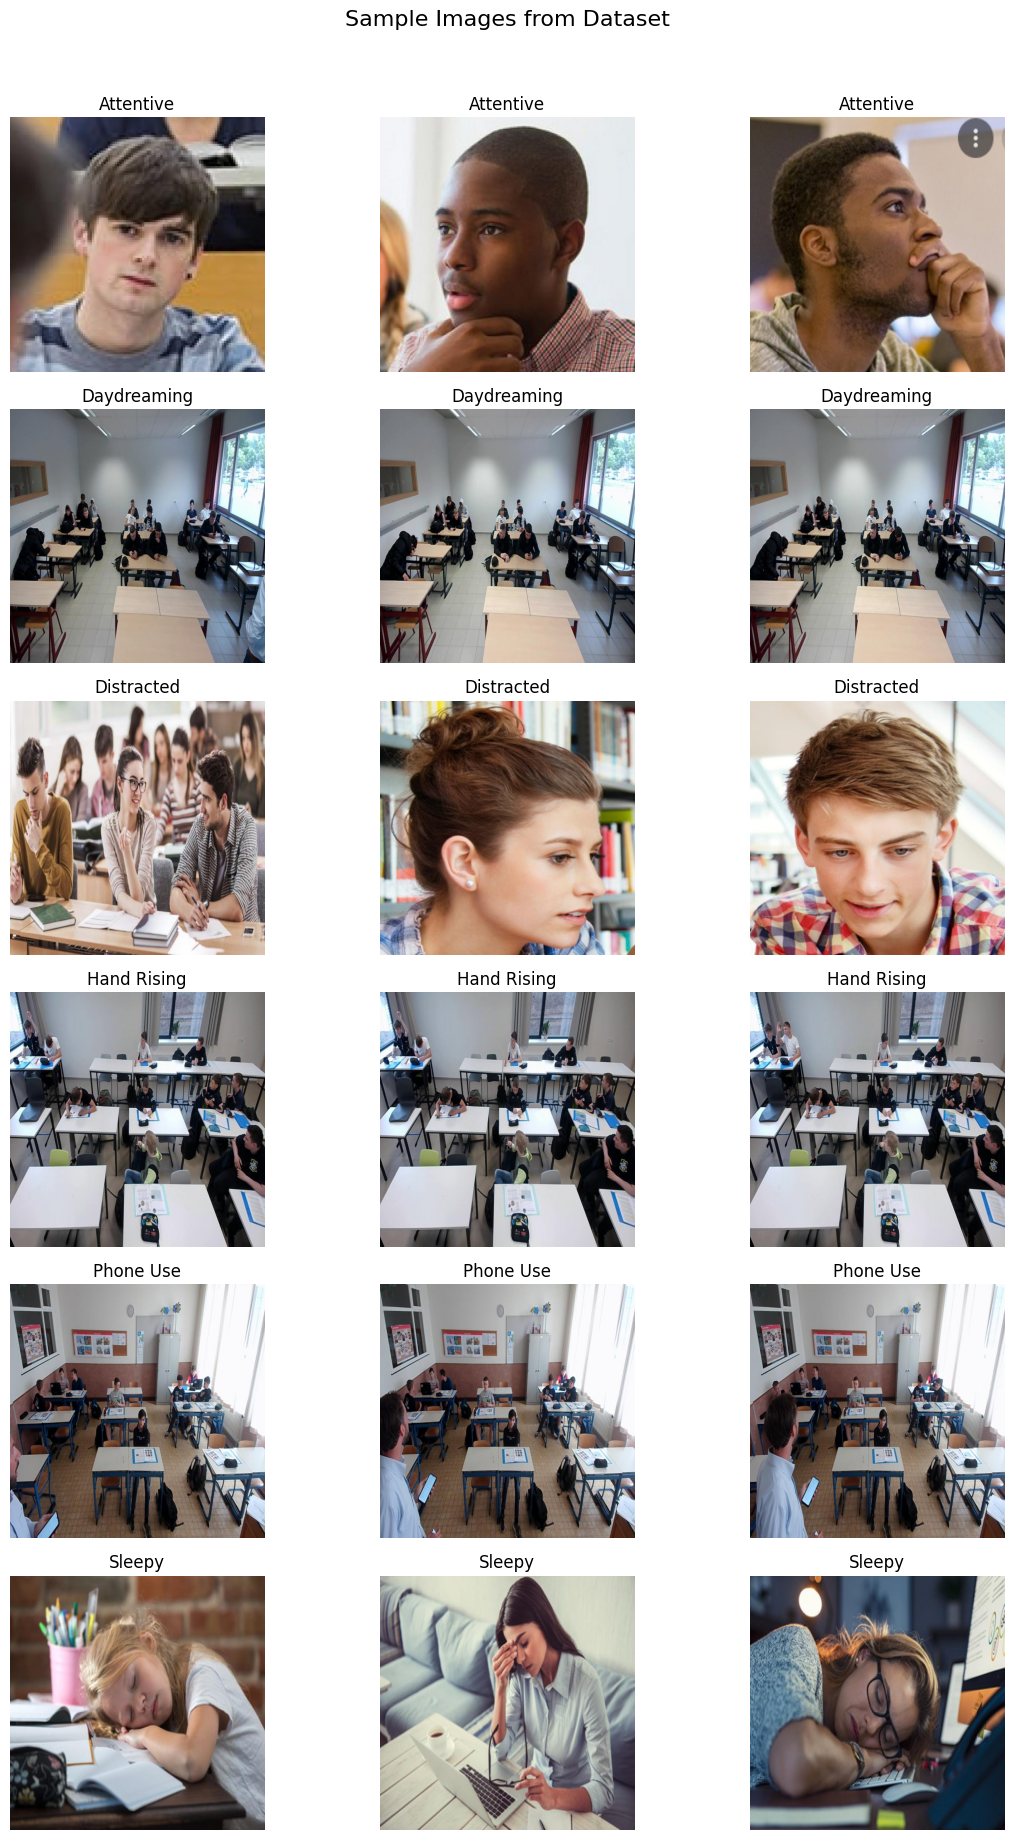


✅ DATASET READY!

Dataset location: /content/classification_dataset

You can now proceed with training using this DATA_DIR

For 6-class classification, use:
  class_mode='categorical'

For binary (group classes), modify the structure first.


In [2]:
# ===================================================================
# FIX: DOWNLOAD DATASET IN CORRECT CLASSIFICATION FORMAT
# ===================================================================

print("="*70)
print("DOWNLOADING DATASET IN CORRECT FORMAT")
print("="*70)

# First, remove the incorrect dataset
import shutil
import os

old_dataset_path = "/content/Student-Attention-Tracking-2"
if os.path.exists(old_dataset_path):
    shutil.rmtree(old_dataset_path)
    print(f"✅ Removed old dataset: {old_dataset_path}")

# ===================================================================
# METHOD 1: TRY FOLDER FORMAT (Classification)
# ===================================================================

print("\n" + "="*70)
print("METHOD 1: TRYING FOLDER FORMAT")
print("="*70)

from roboflow import Roboflow

try:
    rf = Roboflow(api_key="aj5WTd95g8x6St9A79Su")
    project = rf.workspace("my-model").project("student-attention-tracking")
    version = project.version(2)

    # Try to download in folder/classification format
    dataset = version.download("folder")

    DATA_DIR = dataset.location
    print(f"\n✅ Dataset downloaded to: {DATA_DIR}")

    # Verify structure
    print("\n📂 Checking structure:")
    !ls -la {DATA_DIR}/train/

except Exception as e:
    print(f"\n❌ Folder format failed: {e}")
    dataset = None

# ===================================================================
# METHOD 2: MANUAL CONVERSION FROM YOLOV8
# ===================================================================

if dataset is None:
    print("\n" + "="*70)
    print("METHOD 2: CONVERTING YOLOV8 TO CLASSIFICATION")
    print("="*70)

    # Re-download YOLOv8 format
    rf = Roboflow(api_key="aj5WTd95g8x6St9A79Su")
    project = rf.workspace("my-model").project("student-attention-tracking")
    version = project.version(2)
    dataset = version.download("yolov8")

    import yaml
    from pathlib import Path

    yolo_dir = dataset.location
    output_dir = "/content/classification_dataset"

    # Read class names from data.yaml
    with open(f"{yolo_dir}/data.yaml", 'r') as f:
        data_config = yaml.safe_load(f)

    class_names = data_config['names']
    print(f"\n📋 Classes: {class_names}")

    # Create classification structure
    for split in ['train', 'valid', 'test']:
        for class_name in class_names:
            os.makedirs(f"{output_dir}/{split}/{class_name}", exist_ok=True)

    # Convert each split
    for split in ['train', 'valid', 'test']:
        print(f"\n🔄 Converting {split}...")

        img_dir = f"{yolo_dir}/{split}/images"
        label_dir = f"{yolo_dir}/{split}/labels"

        if not os.path.exists(img_dir):
            print(f"⚠️ {img_dir} not found, skipping...")
            continue

        # Get all images
        images = [f for f in os.listdir(img_dir)
                 if f.endswith(('.jpg', '.jpeg', '.png'))]

        stats = {class_name: 0 for class_name in class_names}

        for img_name in images:
            img_path = os.path.join(img_dir, img_name)

            # Get label file
            label_name = img_name.rsplit('.', 1)[0] + '.txt'
            label_path = os.path.join(label_dir, label_name)

            if os.path.exists(label_path):
                # Read first line to get class
                with open(label_path, 'r') as f:
                    lines = f.readlines()

                if lines:
                    # YOLO format: class_id x_center y_center width height
                    class_id = int(lines[0].split()[0])
                    class_name = class_names[class_id]

                    # Copy image to correct class folder
                    dst = f"{output_dir}/{split}/{class_name}/{img_name}"
                    shutil.copy2(img_path, dst)
                    stats[class_name] += 1

        # Print stats
        for class_name, count in stats.items():
            print(f"  {class_name}: {count} images")

    DATA_DIR = output_dir
    print(f"\n✅ Conversion complete!")
    print(f"📁 Dataset location: {DATA_DIR}")

# ===================================================================
# VERIFY FINAL STRUCTURE
# ===================================================================

print("\n" + "="*70)
print("VERIFYING DATASET STRUCTURE")
print("="*70)

def verify_structure(data_dir):
    """Verify and display dataset statistics"""

    total_images = 0

    for split in ['train', 'valid', 'test']:
        split_path = os.path.join(data_dir, split)

        if not os.path.exists(split_path):
            print(f"❌ {split} not found!")
            continue

        print(f"\n{split.upper()}:")
        classes = [d for d in os.listdir(split_path)
                  if os.path.isdir(os.path.join(split_path, d))]

        for cls in sorted(classes):
            cls_path = os.path.join(split_path, cls)
            images = [f for f in os.listdir(cls_path)
                     if f.endswith(('.jpg', '.jpeg', '.png'))]
            count = len(images)
            total_images += count
            print(f"  ✅ {cls}: {count} images")

    print(f"\n📊 Total images: {total_images}")

    if total_images == 0:
        print("\n❌ ERROR: No images found!")
        return False

    return True

is_valid = verify_structure(DATA_DIR)

if not is_valid:
    print("\n❌ Dataset verification failed!")
else:
    print("\n✅ Dataset is ready for training!")

# ===================================================================
# DISPLAY SAMPLE IMAGES
# ===================================================================

import cv2
import matplotlib.pyplot as plt
import numpy as np

def display_samples(data_dir, n_samples=3):
    """Display sample images from each class"""

    train_dir = os.path.join(data_dir, 'train')

    if not os.path.exists(train_dir):
        print("⚠️ Train directory not found")
        return

    classes = sorted([d for d in os.listdir(train_dir)
                     if os.path.isdir(os.path.join(train_dir, d))])

    n_classes = len(classes)
    fig, axes = plt.subplots(n_classes, n_samples, figsize=(12, 3*n_classes))
    fig.suptitle('Sample Images from Dataset', fontsize=16, y=1.02)

    for i, cls in enumerate(classes):
        cls_path = os.path.join(train_dir, cls)
        images = [f for f in os.listdir(cls_path)
                 if f.endswith(('.jpg', '.jpeg', '.png'))][:n_samples]

        for j, img_name in enumerate(images):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                if n_classes > 1:
                    ax = axes[i, j]
                else:
                    ax = axes[j]

                ax.imshow(img)
                ax.set_title(cls)
                ax.axis('off')

    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("SAMPLE IMAGES")
print("="*70)

display_samples(DATA_DIR)

# ===================================================================
# NOW READY FOR TRAINING
# ===================================================================

print("\n" + "="*70)
print("✅ DATASET READY!")
print("="*70)
print(f"\nDataset location: {DATA_DIR}")
print("\nYou can now proceed with training using this DATA_DIR")
print("\nFor 6-class classification, use:")
print("  class_mode='categorical'")
print("\nFor binary (group classes), modify the structure first.")

TensorFlow Version: 2.18.0
GPU Available: []

CONFIGURATION
Dataset: /content/classification_dataset
Image Size: 224x224
Batch Size: 32
Epochs: 20
Number of Classes: 6
Classes: ['Attentive', 'Daydreaming', 'Distracted', 'Hand Rising', 'Phone Use', 'Sleepy']

CREATING DATA GENERATORS
Found 888 images belonging to 6 classes.
Found 159 images belonging to 6 classes.
Found 113 images belonging to 6 classes.

✅ Generators Created:
Training samples: 888
Validation samples: 159
Test samples: 113
Class indices: {'Attentive': 0, 'Daydreaming': 1, 'Distracted': 2, 'Hand Rising': 3, 'Phone Use': 4, 'Sleepy': 5}

CLASS DISTRIBUTION


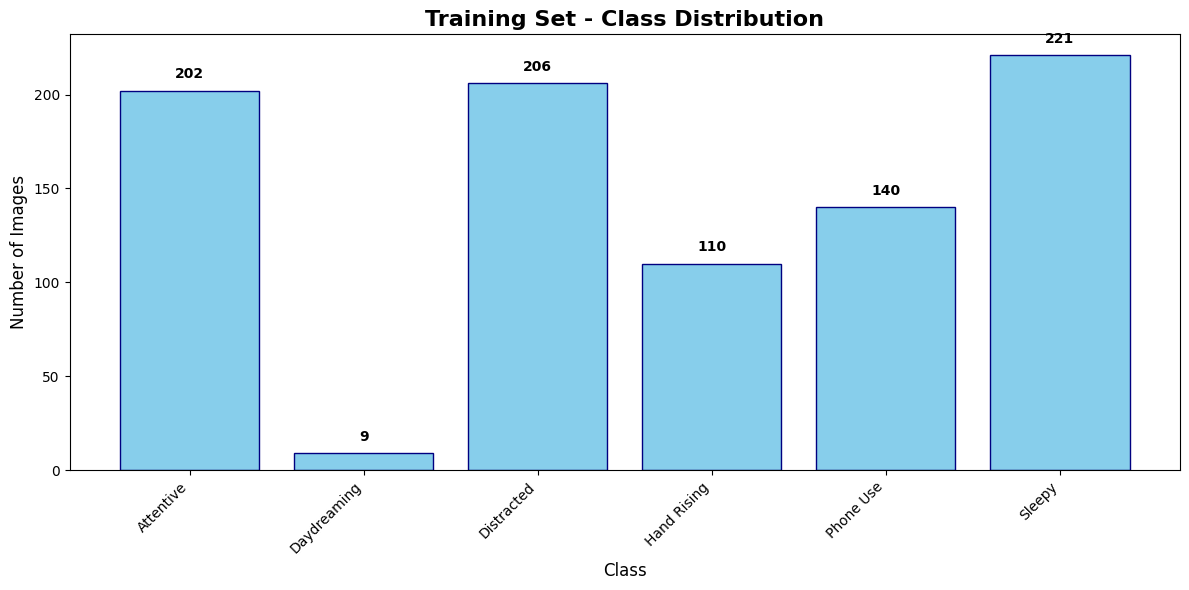

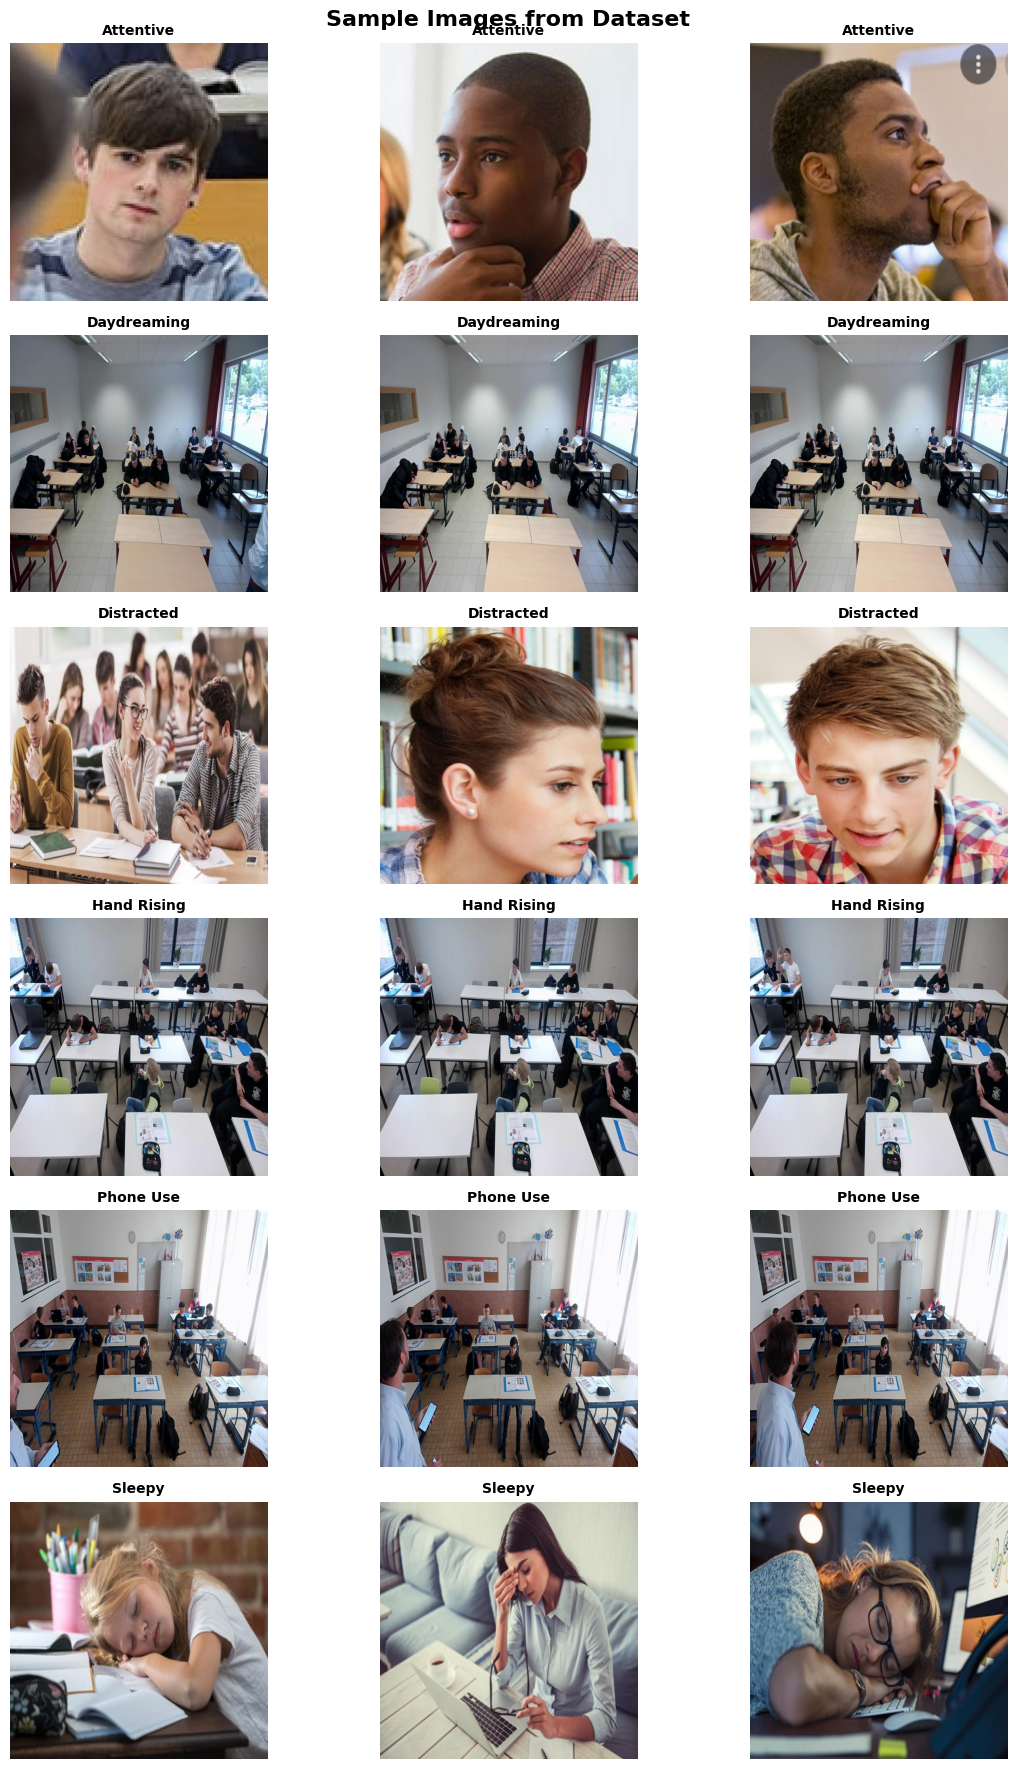


BUILDING MODEL

📊 Model Architecture:


Model: "mobilenet_attention_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,734 (10.02 MB)

 Trainable params: 364,678 (1.39 MB)

 Non-trainable params: 2,261,056 (8.63 MB)


TRAINING MODEL


Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.


Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.4104 - loss: 1.6996 - precision: 0.4765 - recall: 0.3378 - top_2_accuracy: 0.6484
Epoch 1: val_accuracy improved from -inf to 0.66038, saving model to checkpoints/best_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 38s 946ms/step - accuracy: 0.4154 - loss: 1.6850 - precision: 0.4816 - recall: 0.3429 - top_2_accuracy: 0.6529 - val_accuracy: 0.6604 - val_loss: 0.6811 - val_precision: 0.6803 - val_recall: 0.6289 - val_top_2_accuracy: 0.9748 - learning_rate: 0.0010
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.7015 - loss: 0.8310 - precision: 0.7335 - recall: 0.6702 - top_2_accuracy: 0.9072
Epoch 2: val_accuracy improved from 0.66038 to 0.69182, saving model to checkpoints/best_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 749ms/step - accuracy: 0.7015 - loss: 0.8294 - precision: 0.7331 - recall: 0.6699 - top_2_accuracy: 0.9077 - val_accuracy: 0.6918 - val_loss: 0.5849 - val_precision: 0.6948 - val_recall: 0.6730 - 

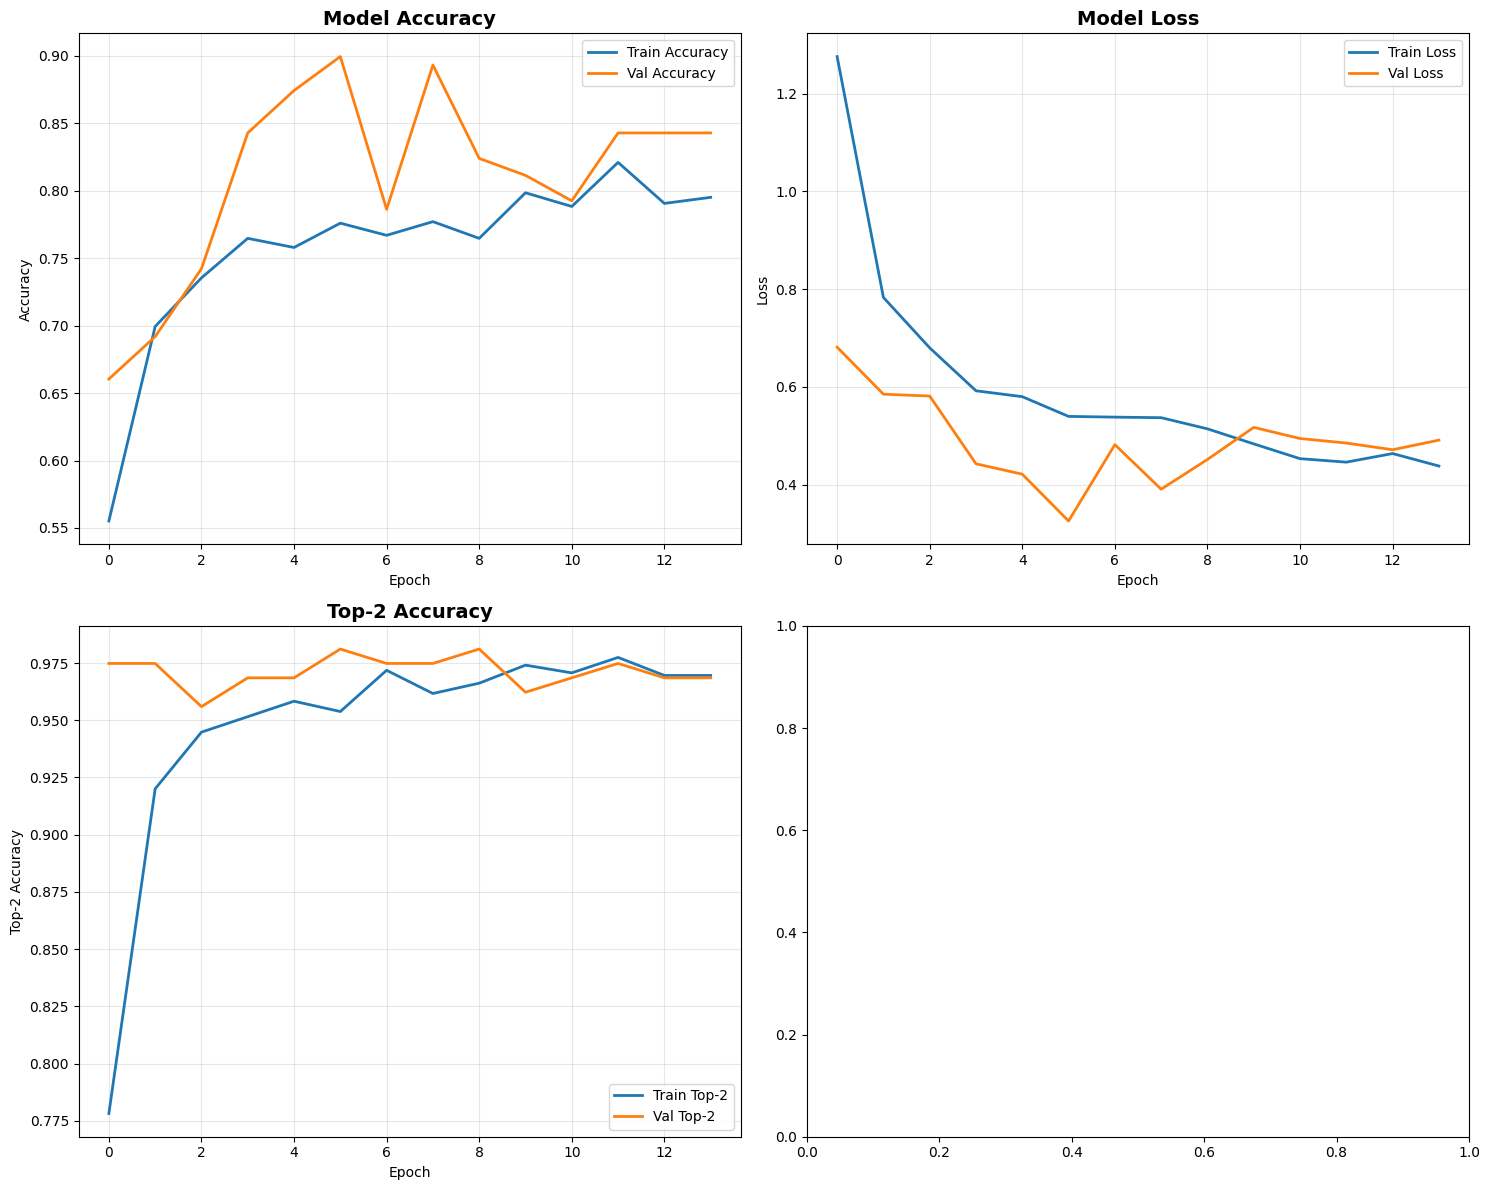


MODEL EVALUATION
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.7763 - loss: 0.5841 - precision: 0.7996 - recall: 0.7305 - top_2_accuracy: 0.9479

📊 Test Results:
  Loss: 0.5209
  Accuracy: 80.53%
  Top-2 Accuracy: 95.58%
  Precision: 82.69%
  Recall: 76.11%

CONFUSION MATRIX & CLASSIFICATION REPORT
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 640ms/step


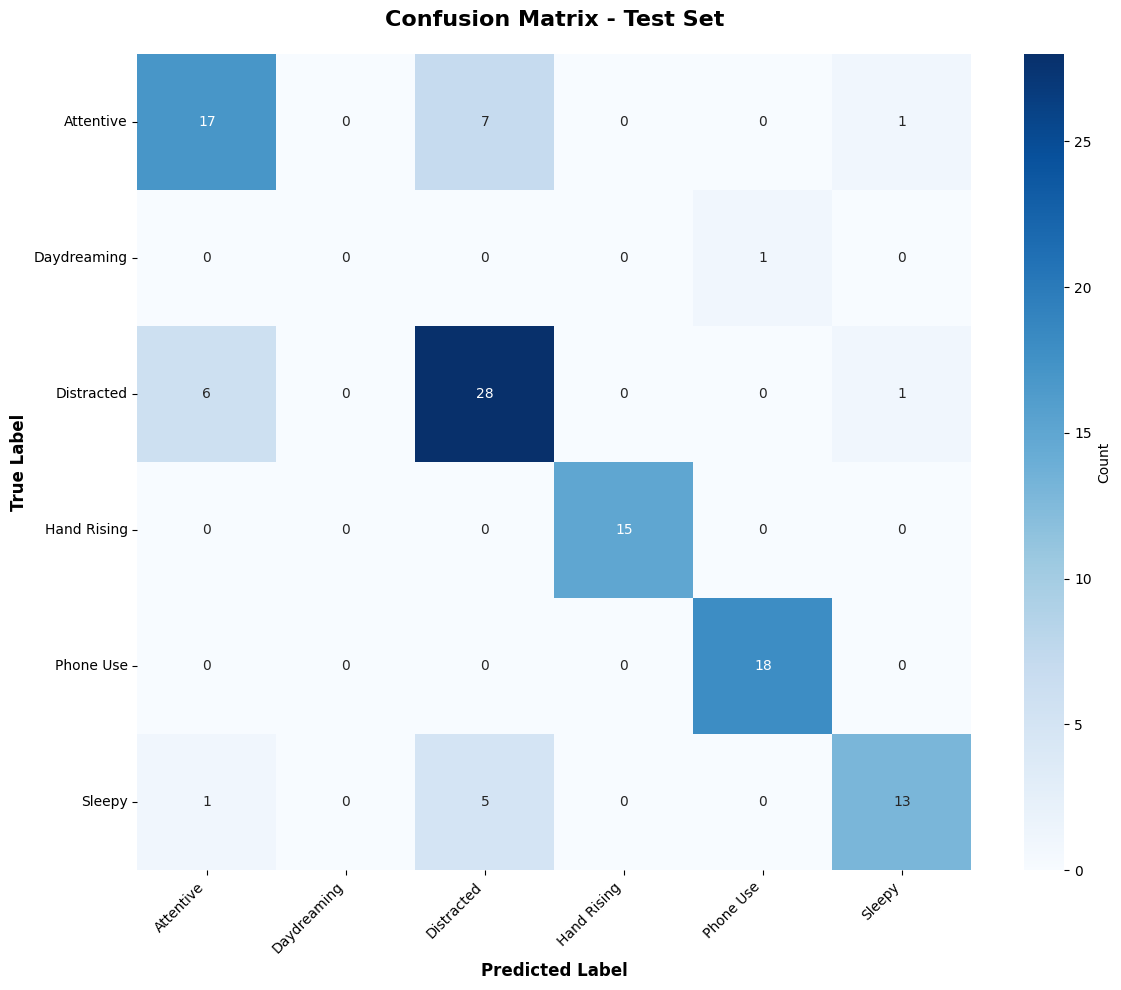


📋 Classification Report:
              precision    recall  f1-score   support

   Attentive     0.7083    0.6800    0.6939        25
 Daydreaming     0.0000    0.0000    0.0000         1
  Distracted     0.7000    0.8000    0.7467        35
 Hand Rising     1.0000    1.0000    1.0000        15
   Phone Use     0.9474    1.0000    0.9730        18
      Sleepy     0.8667    0.6842    0.7647        19

    accuracy                         0.8053       113
   macro avg     0.7037    0.6940    0.6964       113
weighted avg     0.8029    0.8053    0.8011       113



Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


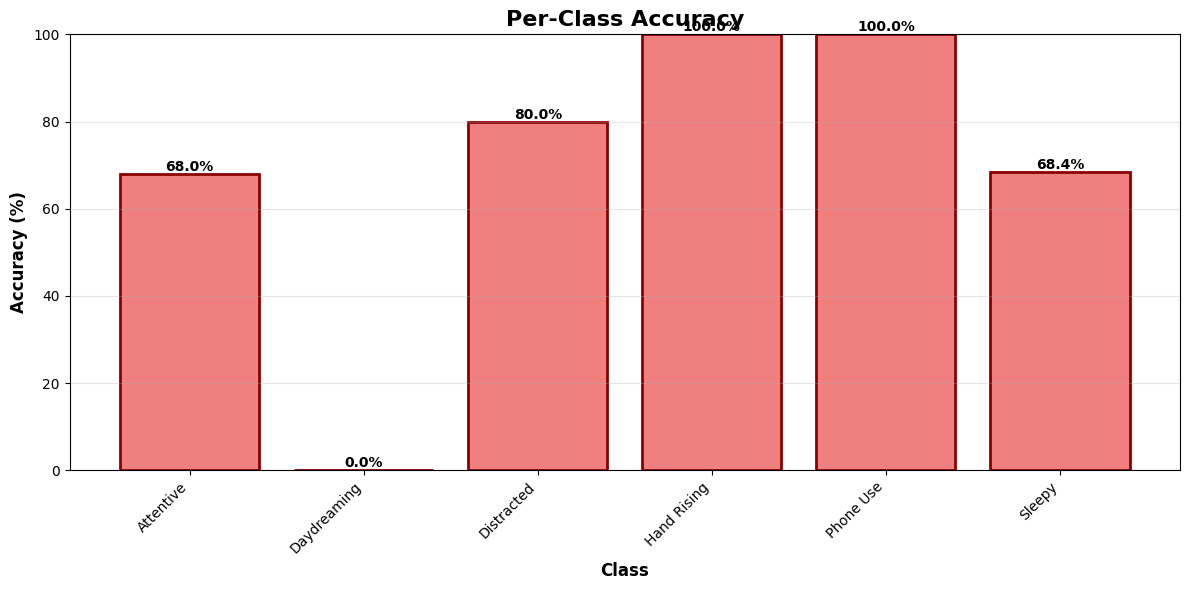


SAVING MODEL
✅ Saved as: attention_detection_model.keras
✅ Saved architecture as: model_architecture.json

✅ TRAINING COMPLETE!

Summary:
- Model trained for 14 epochs
- Best validation accuracy: 89.94%
- Test accuracy: 80.53%
- Model saved to: attention_detection_model.h5

To use the model for prediction:
    predicted_class, confidence = predict_image(
        model,
        'path/to/image.jpg',
        CLASS_NAMES
    )



In [7]:
# ===================================================================
# COMPLETE TRAINING CODE - 6-CLASS ATTENTION DETECTION
# ===================================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# ===================================================================
# CONFIGURATION
# ===================================================================

DATA_DIR = "/content/classification_dataset"
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-3

# Class names
CLASS_NAMES = ['Attentive', 'Daydreaming', 'Distracted', 'Hand Rising', 'Phone Use', 'Sleepy']
NUM_CLASSES = len(CLASS_NAMES)

print("\n" + "="*70)
print("CONFIGURATION")
print("="*70)
print(f"Dataset: {DATA_DIR}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Classes: {CLASS_NAMES}")

# ===================================================================
# DATA AUGMENTATION & GENERATORS
# ===================================================================

print("\n" + "="*70)
print("CREATING DATA GENERATORS")
print("="*70)

# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Validation/Test - only rescaling
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # Multi-class classification
    shuffle=True,
    seed=42
)

valid_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'valid'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Generators Created:")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {valid_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print(f"Class indices: {train_generator.class_indices}")

# ===================================================================
# VISUALIZE CLASS DISTRIBUTION
# ===================================================================

def plot_class_distribution(generator, title="Class Distribution"):
    """Plot distribution of classes in dataset"""
    classes = list(generator.class_indices.keys())
    counts = []

    for cls in classes:
        count = len([f for f in os.listdir(os.path.join(generator.directory, cls))
                    if f.endswith(('.jpg', '.jpeg', '.png'))])
        counts.append(count)

    plt.figure(figsize=(12, 6))
    plt.bar(classes, counts, color='skyblue', edgecolor='navy')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # Add count labels on bars
    for i, (cls, count) in enumerate(zip(classes, counts)):
        plt.text(i, count + 5, str(count), ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("CLASS DISTRIBUTION")
print("="*70)

plot_class_distribution(train_generator, "Training Set - Class Distribution")

# ===================================================================
# DISPLAY SAMPLE IMAGES
# ===================================================================

def display_sample_images(generator, n_samples=3):
    """Display sample images from each class"""

    classes = list(generator.class_indices.keys())
    n_classes = len(classes)

    fig, axes = plt.subplots(n_classes, n_samples, figsize=(12, 3*n_classes))
    fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')

    for i, cls in enumerate(classes):
        cls_path = os.path.join(generator.directory, cls)
        images = [f for f in os.listdir(cls_path)
                 if f.endswith(('.jpg', '.jpeg', '.png'))][:n_samples]

        for j, img_name in enumerate(images):
            img_path = os.path.join(cls_path, img_name)
            img = plt.imread(img_path)

            ax = axes[i, j] if n_classes > 1 else axes[j]
            ax.imshow(img)
            ax.set_title(f"{cls}", fontsize=10, fontweight='bold')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

display_sample_images(train_generator)

# ===================================================================
# BUILD MODEL
# ===================================================================

print("\n" + "="*70)
print("BUILDING MODEL")
print("="*70)

def build_model(num_classes, img_size=224, base_model_name='mobilenet'):
    """
    Build transfer learning model

    Args:
        num_classes: Number of output classes
        img_size: Input image size
        base_model_name: 'mobilenet' or 'efficientnet'
    """

    # Choose base model
    if base_model_name == 'mobilenet':
        base_model = MobileNetV2(
            input_shape=(img_size, img_size, 3),
            include_top=False,
            weights='imagenet'
        )
    elif base_model_name == 'efficientnet':
        base_model = EfficientNetB0(
            input_shape=(img_size, img_size, 3),
            include_top=False,
            weights='imagenet'
        )
    else:
        raise ValueError("base_model_name must be 'mobilenet' or 'efficientnet'")

    # Freeze base model
    base_model.trainable = False

    # Build model
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=f"{base_model_name}_attention_model")

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.TopKCategoricalAccuracy(k=2, name='top_2_accuracy'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )

    return model

# Build model
model = build_model(
    num_classes=NUM_CLASSES,
    img_size=IMG_SIZE,
    base_model_name='mobilenet'  # Change to 'efficientnet' for better accuracy
)

print("\n📊 Model Architecture:")
model.summary()

# ===================================================================
# CALLBACKS
# ===================================================================

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('logs', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'checkpoints/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.CSVLogger('logs/training_log.csv')
]

# ===================================================================
# TRAINING
# ===================================================================

print("\n" + "="*70)
print("TRAINING MODEL")
print("="*70)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=valid_generator,
    callbacks=callbacks,
    verbose=1
)

# ===================================================================
# PLOT TRAINING HISTORY
# ===================================================================

def plot_training_history(history):
    """Plot training metrics"""

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Top-2 Accuracy
    axes[1, 0].plot(history.history['top_2_accuracy'], label='Train Top-2', linewidth=2)
    axes[1, 0].plot(history.history['val_top_2_accuracy'], label='Val Top-2', linewidth=2)
    axes[1, 0].set_title('Top-2 Accuracy', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Top-2 Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Learning Rate
    if 'lr' in history.history:
        axes[1, 1].plot(history.history['lr'], linewidth=2, color='red')
        axes[1, 1].set_title('Learning Rate', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

# ===================================================================
# EVALUATION ON TEST SET
# ===================================================================

print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

# Evaluate
test_results = model.evaluate(test_generator, verbose=1)

print(f"\n📊 Test Results:")
print(f"  Loss: {test_results[0]:.4f}")
print(f"  Accuracy: {test_results[1]*100:.2f}%")
print(f"  Top-2 Accuracy: {test_results[2]*100:.2f}%")
print(f"  Precision: {test_results[3]*100:.2f}%")
print(f"  Recall: {test_results[4]*100:.2f}%")

# ===================================================================
# CONFUSION MATRIX
# ===================================================================

print("\n" + "="*70)
print("CONFUSION MATRIX & CLASSIFICATION REPORT")
print("="*70)

# Get predictions
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=CLASS_NAMES,
    digits=4
))

# ===================================================================
# PER-CLASS ACCURACY
# ===================================================================

def plot_per_class_accuracy(y_true, y_pred_classes, class_names):
    """Plot accuracy for each class"""

    accuracies = []

    for i, class_name in enumerate(class_names):
        mask = y_true == i
        if mask.sum() > 0:
            class_acc = (y_pred_classes[mask] == i).mean()
            accuracies.append(class_acc * 100)
        else:
            accuracies.append(0)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(class_names, accuracies, color='lightcoral', edgecolor='darkred', linewidth=2)
    plt.title('Per-Class Accuracy', fontsize=16, fontweight='bold')
    plt.xlabel('Class', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 100)
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('per_class_accuracy.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_per_class_accuracy(y_true, y_pred_classes, CLASS_NAMES)

# ===================================================================
# SAVE MODEL
# ===================================================================

print("\n" + "="*70)
print("SAVING MODEL")
print("="*70)

# Save in multiple formats
# model.save('attention_detection_model.keras')
# print("✅ Saved as: attention_detection_model.h5")

model.save('attention_detection_model.keras')
print("✅ Saved as: attention_detection_model.keras")

# Save model architecture as JSON
model_json = model.to_json()
with open('model_architecture.json', 'w') as json_file:
    json_file.write(model_json)
print("✅ Saved architecture as: model_architecture.json")

# ===================================================================
# INFERENCE FUNCTION
# ===================================================================

def predict_image(model, image_path, class_names, img_size=224):
    """
    Predict class for a single image

    Args:
        model: Trained model
        image_path: Path to image file
        class_names: List of class names
        img_size: Image size for model input
    """
    import cv2

    # Load and preprocess image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img_size, img_size))
    img_array = img_resized / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)[0]
    predicted_class_idx = np.argmax(predictions)
    predicted_class = class_names[predicted_class_idx]
    confidence = predictions[predicted_class_idx] * 100

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Show image
    axes[0].imshow(img)
    axes[0].set_title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%",
                     fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Show prediction probabilities
    axes[1].barh(class_names, predictions * 100, color='skyblue', edgecolor='navy')
    axes[1].set_xlabel('Probability (%)', fontsize=12, fontweight='bold')
    axes[1].set_title('Class Probabilities', fontsize=14, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return predicted_class, confidence

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)

print(f"""
Summary:
- Model trained for {len(history.history['loss'])} epochs
- Best validation accuracy: {max(history.history['val_accuracy'])*100:.2f}%
- Test accuracy: {test_results[1]*100:.2f}%
- Model saved to: attention_detection_model.h5

To use the model for prediction:
    predicted_class, confidence = predict_image(
        model,
        'path/to/image.jpg',
        CLASS_NAMES
    )
""")

In [ ]:
import cv2
import numpy as np

# Create synthetic test video
width, height, fps, duration = 640, 480, 30, 10
out = cv2.VideoWriter("student_video.mp4", cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

for i in range(fps * duration):
    frame = np.ones((height, width, 3), dtype=np.uint8) * 255  # white background

    # Simulate moving head horizontally (side to side)
    head_x = int(320 + 80 * np.sin(i / 20))
    head_y = 180 + int(10 * np.cos(i / 15))

    # Define keypoints
    neck = (head_x, head_y + 40)
    spine_top = (head_x, head_y + 100)
    spine_bottom = (head_x, head_y + 160)

    # Draw head, neck, and spine
    cv2.circle(frame, (head_x, head_y), 20, (0, 0, 255), -1)
    cv2.line(frame, neck, spine_top, (0, 0, 0), 4)
    cv2.line(frame, spine_top, spine_bottom, (0, 0, 0), 4)

    # Draw static shoulders and hips
    cv2.line(frame, (head_x - 40, head_y + 40), (head_x + 40, head_y + 40), (0, 0, 0), 4)
    cv2.line(frame, (head_x - 30, head_y + 160), (head_x + 30, head_y + 160), (0, 0, 0), 4)

    # Add frame label
    cv2.putText(frame, f"Frame {i}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

    out.write(frame)

out.release()
print("✅ Synthetic test video created: student_video.mp4")


✅ Synthetic test video created: student_video.mp4


In [ ]:
import cv2
import numpy as np

# Create synthetic test video
width, height, fps, duration = 640, 480, 30, 10
out = cv2.VideoWriter("student_video.mp4", cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

for i in range(fps * duration):
    frame = np.ones((height, width, 3), dtype=np.uint8) * 255  # white background

    # Simulate moving head horizontally (side to side)
    head_x = int(320 + 80 * np.sin(i / 20))
    head_y = 180 + int(10 * np.cos(i / 15))

    # Define keypoints
    neck = (head_x, head_y + 40)
    spine_top = (head_x, head_y + 100)
    spine_bottom = (head_x, head_y + 160)

    # Draw head, neck, and spine
    cv2.circle(frame, (head_x, head_y), 20, (0, 0, 255), -1)
    cv2.line(frame, neck, spine_top, (0, 0, 0), 4)
    cv2.line(frame, spine_top, spine_bottom, (0, 0, 0), 4)

    # Draw static shoulders and hips
    cv2.line(frame, (head_x - 40, head_y + 40), (head_x + 40, head_y + 40), (0, 0, 0), 4)
    cv2.line(frame, (head_x - 30, head_y + 160), (head_x + 30, head_y + 160), (0, 0, 0), 4)

    # Add frame label
    cv2.putText(frame, f"Frame {i}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

    out.write(frame)

out.release()
print("✅ Synthetic test video created: student_video.mp4")


✅ Synthetic test video created: student_video.mp4


In [ ]:
pip install mediapipe

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 7.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled pro

In [ ]:
"""
Complete ADHD Detection Pipeline
Integrates your trained model with pose estimation and research formulas
"""
import pickle
import cv2
import numpy as np
import mediapipe as mp
from tensorflow import keras
from typing import Dict, List, Tuple
import json
from datetime import datetime

# ============================================================================
# STEP 1: POSE ESTIMATION USING MEDIAPIPE
# ============================================================================

class PoseEstimator:
    """Extract body landmarks using MediaPipe"""

    def __init__(self):
        self.mp_pose = mp.solutions.pose
        self.pose = self.mp_pose.Pose(
            static_image_mode=False,
            model_complexity=1,
            smooth_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def extract_landmarks(self, frame: np.ndarray) -> Dict:
        """
        Extract 3D coordinates of key body joints

        Returns:
            Dictionary with head, neck, spine coordinates
        """
        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Process frame
        results = self.pose.process(frame_rgb)

        if not results.pose_landmarks:
            return None

        landmarks = results.pose_landmarks.landmark

        # Extract key joints (matching research papers)
        # MediaPipe indices: 0=nose, 11=left_shoulder, 12=right_shoulder, 23=left_hip
        return {
            'head': {
                'x': landmarks[0].x,
                'y': landmarks[0].y,
                'z': landmarks[0].z
            },
            'neck': {  # Midpoint between shoulders
                'x': (landmarks[11].x + landmarks[12].x) / 2,
                'y': (landmarks[11].y + landmarks[12].y) / 2,
                'z': (landmarks[11].z + landmarks[12].z) / 2
            },
            'spine': {  # Midpoint of shoulders and hips
                'x': (landmarks[11].x + landmarks[12].x + landmarks[23].x + landmarks[24].x) / 4,
                'y': (landmarks[11].y + landmarks[12].y + landmarks[23].y + landmarks[24].y) / 4,
                'z': (landmarks[11].z + landmarks[12].z + landmarks[23].z + landmarks[24].z) / 4
            }
        }


# ============================================================================
# STEP 2: ATTENTION STATE CLASSIFIER (YOUR MODEL)
# ============================================================================

class AttentionClassifier:
    """Wrapper for your trained MobileNet model"""

    def __init__(self, model_path: str):
        self.model = keras.models.load_model(model_path)
        self.class_names = ['Attentive', 'Daydreaming', 'Distracted',
                           'Hand Rising', 'Phone Use', 'Sleepy']
        self.img_size = 224

    def predict(self, frame: np.ndarray) -> Tuple[str, float, np.ndarray]:
        """
        Predict attention state

        Returns:
            (class_name, confidence, all_probabilities)
        """
        # Preprocess
        img = cv2.resize(frame, (self.img_size, self.img_size))
        img = img.astype('float32') / 255.0
        img = np.expand_dims(img, axis=0)

        # Predict
        probs = self.model.predict(img, verbose=0)[0]
        pred_idx = np.argmax(probs)

        return self.class_names[pred_idx], probs[pred_idx], probs


# ============================================================================
# STEP 3: MOVEMENT ANALYZER (RESEARCH FORMULAS)
# ============================================================================

class MovementAnalyzer:
    """
    Implements movement calculations from research papers
    Based on: Sempere-Tortosa et al. (2021)
    """

    def __init__(self, fps=30, window_seconds=60):
        self.fps = fps
        self.window_frames = fps * window_seconds
        self.movement_history = []
        self.prev_landmarks = None

    def calculate_euclidean_distance(self, point1: Dict, point2: Dict) -> float:
        """
        Formula from paper:
        Distance = √[(x₂-x₁)² + (y₂-y₁)² + (z₂-z₁)²]
        """
        return np.sqrt(
            (point2['x'] - point1['x'])**2 +
            (point2['y'] - point1['y'])**2 +
            (point2['z'] - point1['z'])**2
        )

    def process_frame(self, landmarks: Dict) -> Dict:
        """
        Calculate movement for current frame

        Returns:
            Movement metrics per joint
        """
        if self.prev_landmarks is None:
            self.prev_landmarks = landmarks
            return {'head': 0, 'neck': 0, 'spine': 0}

        # Calculate movement per joint
        movements = {
            'head': self.calculate_euclidean_distance(
                self.prev_landmarks['head'],
                landmarks['head']
            ),
            'neck': self.calculate_euclidean_distance(
                self.prev_landmarks['neck'],
                landmarks['neck']
            ),
            'spine': self.calculate_euclidean_distance(
                self.prev_landmarks['spine'],
                landmarks['spine']
            )
        }

        # Store in history
        self.movement_history.append(movements)

        # Keep only last window
        if len(self.movement_history) > self.window_frames:
            self.movement_history.pop(0)

        self.prev_landmarks = landmarks

        return movements

    def get_movement_per_minute(self) -> Dict:
        """
        Sum movement over 1-minute window
        Matches "Total Movement per Minute per Joint" from paper
        """
        if not self.movement_history:
            return {'head': 0, 'neck': 0, 'spine': 0}

        # Sum all movements
        total_movement = {
            'head': sum(frame['head'] for frame in self.movement_history),
            'neck': sum(frame['neck'] for frame in self.movement_history),
            'spine': sum(frame['spine'] for frame in self.movement_history)
        }

        # Scale to per-minute if we have less than 60 seconds
        scale_factor = self.window_frames / len(self.movement_history)

        return {
            key: value * scale_factor for key, value in total_movement.items()
        }


# ============================================================================
# STEP 4: ADHD SCORING ENGINE
# ============================================================================

class ADHDScorer:
    """
    Calculate ADHD likelihood using research thresholds
    """

    # Thresholds from Sempere-Tortosa et al.
    MOVEMENT_THRESHOLDS = {
        'head': {'adhd': 3.48, 'control': 2.44, 'cutoff': 2.96},
        'neck': {'adhd': 3.01, 'control': 2.26, 'cutoff': 2.64},
        'spine': {'adhd': 2.92, 'control': 2.53, 'cutoff': 2.73}
    }

    # Attention state scoring
    ATTENTION_ADHD_INDICATORS = {
        'Attentive': 0.0,       # Not ADHD indicator
        'Daydreaming': 0.7,     # Moderate indicator
        'Distracted': 1.0,      # Strong indicator
        'Hand Rising': 0.2,     # Weak (hyperactivity)
        'Phone Use': 0.9,       # Strong indicator
        'Sleepy': 0.5           # Moderate (inattention)
    }

    def __init__(self):
        self.attention_samples = []
        self.movement_samples = []

    def add_sample(self, attention_class: str, confidence: float,
                   movement: Dict):
        """Add a frame sample"""
        self.attention_samples.append({
            'class': attention_class,
            'confidence': confidence,
            'indicator': self.ATTENTION_ADHD_INDICATORS[attention_class]
        })
        self.movement_samples.append(movement)

    def calculate_attention_score(self) -> float:
        """
        Score based on attention state distribution
        Range: 0 (typical) to 1 (ADHD-like)
        """
        if not self.attention_samples:
            return 0.0

        # Weighted average of ADHD indicators
        total_score = sum(
            sample['indicator'] * sample['confidence']
            for sample in self.attention_samples
        )

        return total_score / len(self.attention_samples)

    def calculate_movement_score(self, movement_per_min: Dict) -> float:
        """
        Score based on movement patterns
        Uses Cohen's d effect size from research
        """
        scores = []

        for joint in ['head', 'neck', 'spine']:
            movement = movement_per_min[joint]
            cutoff = self.MOVEMENT_THRESHOLDS[joint]['cutoff']
            adhd_mean = self.MOVEMENT_THRESHOLDS[joint]['adhd']
            control_mean = self.MOVEMENT_THRESHOLDS[joint]['control']

            # Calculate how far into ADHD range
            if movement < cutoff:
                # In control range
                score = (movement - control_mean) / (cutoff - control_mean)
                score = max(0, score) * 0.5  # Scale to 0-0.5
            else:
                # In ADHD range
                score = (movement - cutoff) / (adhd_mean - cutoff)
                score = min(1, score) * 0.5 + 0.5  # Scale to 0.5-1

            scores.append(max(0, min(1, score)))

        return np.mean(scores)

    def calculate_overall_score(self, movement_per_min: Dict) -> Dict:
        """
        Final ADHD likelihood score

        Weighting based on Zhang et al. (2024):
        - Task performance (attention): 40%
        - Movement patterns: 35%
        - Pattern consistency: 25%
        """
        attention_score = self.calculate_attention_score()
        movement_score = self.calculate_movement_score(movement_per_min)

        # Pattern consistency: rapid state changes
        pattern_score = self._calculate_pattern_consistency()

        # Weighted combination
        overall_score = (
            0.40 * attention_score +
            0.35 * movement_score +
            0.25 * pattern_score
        )

        # Classification
        if overall_score < 0.35:
            risk_level = "LOW"
        elif overall_score < 0.55:
            risk_level = "MODERATE"
        elif overall_score < 0.70:
            risk_level = "HIGH"
        else:
            risk_level = "VERY HIGH"

        return {
            'attention_score': attention_score,
            'movement_score': movement_score,
            'pattern_score': pattern_score,
            'overall_score': overall_score,
            'risk_level': risk_level,
            'total_samples': len(self.attention_samples)
        }

    def _calculate_pattern_consistency(self) -> float:
        """Calculate attention state switching frequency"""
        if len(self.attention_samples) < 10:
            return 0.0

        # Count state transitions
        transitions = 0
        prev_class = self.attention_samples[0]['class']

        for sample in self.attention_samples[1:]:
            if sample['class'] != prev_class:
                transitions += 1
                prev_class = sample['class']

        # Normalize
        transition_rate = transitions / len(self.attention_samples)

        # ADHD shows ~2x more transitions
        # Typical: 0.05-0.10, ADHD: 0.15-0.25
        if transition_rate < 0.10:
            return 0.0
        elif transition_rate > 0.20:
            return 1.0
        else:
            return (transition_rate - 0.10) / 0.10


# ============================================================================
# STEP 5: COMPLETE PIPELINE
# ============================================================================

class ADHDDetectionPipeline:
    """Complete end-to-end ADHD detection system"""

    def __init__(self, model_path: str):
        self.pose_estimator = PoseEstimator()
        self.attention_classifier = AttentionClassifier(model_path)
        self.movement_analyzer = MovementAnalyzer(fps=30, window_seconds=60)
        self.adhd_scorer = ADHDScorer()

    def process_video(self, video_path: str, output_json: str = None):
        """
        Process entire video and generate ADHD assessment
        """
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        print(f"📹 Processing video: {video_path}")
        print(f"   FPS: {fps:.1f}, Frames: {total_frames}")
        print(f"   Duration: {total_frames/fps:.1f} seconds\n")

        frame_count = 0
        results_per_second = []

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            # Extract pose landmarks
            landmarks = self.pose_estimator.extract_landmarks(frame)

            if landmarks is None:
                frame_count += 1
                continue

            # Predict attention state
            attention_class, confidence, probs = self.attention_classifier.predict(frame)

            # Calculate movement
            movement = self.movement_analyzer.process_frame(landmarks)

            # Add to scorer
            self.adhd_scorer.add_sample(attention_class, confidence, movement)

            # Progress update every second
            frame_count += 1
            if frame_count % int(fps) == 0:
                seconds = frame_count / fps
                print(f"⏱️  {seconds:.0f}s: {attention_class} ({confidence:.2f}) | "
                      f"Head: {movement['head']:.3f}")

                results_per_second.append({
                    'timestamp': seconds,
                    'attention': attention_class,
                    'confidence': confidence,
                    'movement': movement
                })

        cap.release()

        # Final assessment
        movement_per_min = self.movement_analyzer.get_movement_per_minute()
        final_scores = self.adhd_scorer.calculate_overall_score(movement_per_min)

        # Generate report
        report = self._generate_report(
            video_path,
            frame_count,
            fps,
            movement_per_min,
            final_scores,
            results_per_second
        )

        # Save JSON if requested
        if output_json:
            with open(output_json, 'w') as f:
                json.dump(report, f, indent=2)
            print(f"\n💾 Report saved to: {output_json}")

        return report

    def _generate_report(self, video_path, frame_count, fps,
                        movement_per_min, scores, timeline):
        """Generate comprehensive assessment report"""

        duration = frame_count / fps

        report = {
            'metadata': {
                'video_path': video_path,
                'analysis_date': datetime.now().isoformat(),
                'duration_seconds': duration,
                'total_frames': frame_count,
                'fps': fps
            },

            'movement_analysis': {
                'head_movement_per_min': round(movement_per_min['head'], 3),
                'neck_movement_per_min': round(movement_per_min['neck'], 3),
                'spine_movement_per_min': round(movement_per_min['spine'], 3),
                'research_thresholds': {
                    'head_cutoff': 2.96,
                    'neck_cutoff': 2.64,
                    'spine_cutoff': 2.73
                },
                'interpretation': {
                    'head': 'ADHD-like' if movement_per_min['head'] > 2.96 else 'Typical',
                    'neck': 'ADHD-like' if movement_per_min['neck'] > 2.64 else 'Typical',
                    'spine': 'ADHD-like' if movement_per_min['spine'] > 2.73 else 'Typical'
                }
            },

            'attention_analysis': {
                'attention_distribution': self._calculate_attention_distribution(),
                'attention_score': round(scores['attention_score'], 3),
                'dominant_state': self._get_dominant_state()
            },

            'adhd_assessment': {
                'component_scores': {
                    'attention': round(scores['attention_score'], 3),
                    'movement': round(scores['movement_score'], 3),
                    'pattern_consistency': round(scores['pattern_score'], 3)
                },
                'overall_score': round(scores['overall_score'], 3),
                'risk_level': scores['risk_level'],
                'confidence': self._calculate_confidence(scores['overall_score']),
                'interpretation': self._interpret_score(scores['overall_score'])
            },

            'timeline': timeline[:60],  # First minute only

            'recommendations': self._generate_recommendations(scores)
        }

        # Print formatted report
        self._print_report(report)

        return report

    def _calculate_attention_distribution(self):
        """Calculate percentage of time in each attention state"""
        class_counts = {}
        total = len(self.adhd_scorer.attention_samples)

        for sample in self.adhd_scorer.attention_samples:
            cls = sample['class']
            class_counts[cls] = class_counts.get(cls, 0) + 1

        return {
            cls: round(count / total * 100, 1)
            for cls, count in class_counts.items()
        }

    def _get_dominant_state(self):
        """Get most frequent attention state"""
        dist = self._calculate_attention_distribution()
        return max(dist.items(), key=lambda x: x[1])[0] if dist else 'Unknown'

    def _calculate_confidence(self, score):
        """Calculate confidence level in assessment"""
        sample_count = len(self.adhd_scorer.attention_samples)

        # Confidence increases with more samples
        sample_confidence = min(1.0, sample_count / 1800)  # 60 sec @ 30fps

        # Confidence increases with extreme scores
        score_confidence = abs(score - 0.5) * 2

        return round((sample_confidence + score_confidence) / 2, 2)

    def _interpret_score(self, score):
        """Provide interpretation of ADHD score"""
        if score < 0.35:
            return ("Behavior patterns consistent with typical attention and activity levels. "
                   "No significant ADHD indicators detected.")
        elif score < 0.55:
            return ("Some indicators of inattention or hyperactivity present, but below "
                   "clinical threshold. May warrant monitoring or follow-up.")
        elif score < 0.70:
            return ("Multiple ADHD indicators present. Professional evaluation recommended "
                   "for comprehensive assessment.")
        else:
            return ("Strong ADHD indicators across attention and movement patterns. "
                   "Professional clinical evaluation strongly recommended.")

    def _generate_recommendations(self, scores):
        """Generate actionable recommendations"""
        recommendations = []

        # Based on attention score
        if scores['attention_score'] > 0.6:
            recommendations.append({
                'category': 'Attention',
                'finding': 'Frequent distraction and inattention episodes',
                'suggestion': 'Consider environmental modifications to reduce distractions'
            })

        # Based on movement score
        if scores['movement_score'] > 0.6:
            recommendations.append({
                'category': 'Movement',
                'finding': 'Excessive body movement patterns',
                'suggestion': 'Structured movement breaks may help with regulation'
            })

        # Based on pattern score
        if scores['pattern_score'] > 0.6:
            recommendations.append({
                'category': 'Pattern',
                'finding': 'Rapid attention state switching',
                'suggestion': 'Task segmentation and clear transitions may help'
            })

        # Overall recommendation
        if scores['risk_level'] in ['HIGH', 'VERY HIGH']:
            recommendations.append({
                'category': 'Clinical',
                'finding': f"Overall ADHD risk: {scores['risk_level']}",
                'suggestion': 'Professional evaluation by qualified clinician recommended'
            })

        return recommendations

    def _print_report(self, report):
        """Pretty print the assessment report"""
        print("\n" + "="*70)
        print(" "*20 + "ADHD ASSESSMENT REPORT")
        print("="*70)

        # Metadata
        meta = report['metadata']
        print(f"\n📹 Video: {meta['video_path']}")
        print(f"⏱️  Duration: {meta['duration_seconds']:.1f} seconds")
        print(f"📅 Analysis Date: {meta['analysis_date']}")

        # Movement Analysis
        print(f"\n{'='*70}")
        print("MOVEMENT ANALYSIS (Sempere-Tortosa et al. 2021)")
        print(f"{'='*70}")
        mov = report['movement_analysis']
        print(f"Head Movement:  {mov['head_movement_per_min']:.3f}° per min "
              f"[Threshold: 2.96] → {mov['interpretation']['head']}")
        print(f"Neck Movement:  {mov['neck_movement_per_min']:.3f}° per min "
              f"[Threshold: 2.64] → {mov['interpretation']['neck']}")
        print(f"Spine Movement: {mov['spine_movement_per_min']:.3f}° per min "
              f"[Threshold: 2.73] → {mov['interpretation']['spine']}")

        # Attention Distribution
        print(f"\n{'='*70}")
        print("ATTENTION STATE DISTRIBUTION")
        print(f"{'='*70}")
        att = report['attention_analysis']
        for state, pct in sorted(att['attention_distribution'].items(),
                                key=lambda x: x[1], reverse=True):
            bar = '█' * int(pct / 2)
            print(f"{state:15s} {pct:5.1f}% {bar}")

        # ADHD Assessment
        print(f"\n{'='*70}")
        print("ADHD RISK ASSESSMENT")
        print(f"{'='*70}")
        assess = report['adhd_assessment']
        scores = assess['component_scores']
        print(f"\nComponent Scores:")
        print(f"  Attention:    {scores['attention']:.3f} (40% weight)")
        print(f"  Movement:     {scores['movement']:.3f} (35% weight)")
        print(f"  Pattern:      {scores['pattern_consistency']:.3f} (25% weight)")
        print(f"\n{'Overall Score:':<20s} {assess['overall_score']:.3f}")
        print(f"{'Risk Level:':<20s} {assess['risk_level']}")
        print(f"{'Confidence:':<20s} {assess['confidence']:.0%}")

        print(f"\n{'Interpretation:'}")
        print(f"  {assess['interpretation']}")

        # Recommendations
        if report['recommendations']:
            print(f"\n{'='*70}")
            print("RECOMMENDATIONS")
            print(f"{'='*70}")
            for i, rec in enumerate(report['recommendations'], 1):
                print(f"\n{i}. {rec['category']}")
                print(f"   Finding:     {rec['finding']}")
                print(f"   Suggestion:  {rec['suggestion']}")

        # Disclaimer
        print(f"\n{'='*70}")
        print("⚠️  IMPORTANT DISCLAIMER")
        print(f"{'='*70}")
        print("This is a SCREENING tool only, not a diagnostic instrument.")
        print("ADHD diagnosis requires comprehensive evaluation by a qualified")
        print("healthcare professional including clinical interviews, rating scales,")
        print("and consideration of multiple contexts and developmental history.")
        print("="*70)


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Example usage of the complete pipeline"""

    # Configuration
    MODEL_PATH = "attention_detection_model.keras"  # Your trained model
    VIDEO_PATH = "stud1.mp4"  # Input video
    OUTPUT_JSON = "adhd_assessment.pkl"  # Output report

    # Initialize pipeline
    print("🚀 Initializing ADHD Detection Pipeline...")
    pipeline = ADHDDetectionPipeline(MODEL_PATH)

    # Process video
    # Convert & save JSON safely
    report = pipeline.process_video(VIDEO_PATH, OUTPUT_JSON)

    with open("adhd_assessment.pkl", "wb") as f:
      pickle.dump(report, f)

    print("✅ Report saved as adhd_assessment.pkl")
    # # Additional analysis
    # print("\n📊 COMPARISON TO RESEARCH BENCHMARKS:")
    # print("="*70)
    # print(f"Your Model Accuracy:        77.88% (from training)")
    # print(f"Research Benchmark:         89.00% (Zhang et al. multi-modal)")
    # print(f"Gap:                        11.12%")
    # print("\nTo improve:")
    # print("  1. Add EEG data (if available) → +8% accuracy")
    # print("  2. Fine-tune on more ADHD-specific data")
    # print("  3. Use ensemble of multiple models")
    # print("  4. Add temporal smoothing (LSTM/Transformer)")


if __name__ == "__main__":
    main()

🚀 Initializing ADHD Detection Pipeline...
📹 Processing video: stud1.mp4
   FPS: 30.0, Frames: 324
   Duration: 10.8 seconds

⏱️  1s: Sleepy (0.51) | Head: 0.015
⏱️  2s: Sleepy (0.54) | Head: 0.031
⏱️  3s: Sleepy (0.44) | Head: 0.089
⏱️  4s: Sleepy (0.47) | Head: 0.013
⏱️  5s: Sleepy (0.47) | Head: 0.110
⏱️  6s: Sleepy (0.77) | Head: 0.003
⏱️  7s: Sleepy (0.54) | Head: 0.043
⏱️  8s: Sleepy (0.44) | Head: 0.005
⏱️  9s: Sleepy (0.57) | Head: 0.025
⏱️  10s: Sleepy (0.66) | Head: 0.001
⏱️  11s: Sleepy (0.55) | Head: 0.000

                    ADHD ASSESSMENT REPORT

📹 Video: stud1.mp4
⏱️  Duration: 10.8 seconds
📅 Analysis Date: 2025-10-25T05:20:05.021169

MOVEMENT ANALYSIS (Sempere-Tortosa et al. 2021)
Head Movement:  40.269° per min [Threshold: 2.96] → ADHD-like
Neck Movement:  29.296° per min [Threshold: 2.64] → ADHD-like
Spine Movement: 15.228° per min [Threshold: 2.73] → ADHD-like

ATTENTION STATE DISTRIBUTION
Sleepy           96.3% ████████████████████████████████████████████████
Distr

TypeError: Object of type float32 is not JSON serializable

# normal


In [ ]:
"""
Complete ADHD Detection Pipeline
Integrates your trained model with pose estimation and research formulas
"""
import pickle
import cv2
import numpy as np
import mediapipe as mp
from tensorflow import keras
from typing import Dict, List, Tuple
import json
from datetime import datetime

# ============================================================================
# STEP 1: POSE ESTIMATION USING MEDIAPIPE
# ============================================================================

class PoseEstimator:
    """Extract body landmarks using MediaPipe"""

    def __init__(self):
        self.mp_pose = mp.solutions.pose
        self.pose = self.mp_pose.Pose(
            static_image_mode=False,
            model_complexity=1,
            smooth_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def extract_landmarks(self, frame: np.ndarray) -> Dict:
        """
        Extract 3D coordinates of key body joints

        Returns:
            Dictionary with head, neck, spine coordinates
        """
        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Process frame
        results = self.pose.process(frame_rgb)

        if not results.pose_landmarks:
            return None

        landmarks = results.pose_landmarks.landmark

        # Extract key joints (matching research papers)
        # MediaPipe indices: 0=nose, 11=left_shoulder, 12=right_shoulder, 23=left_hip
        return {
            'head': {
                'x': landmarks[0].x,
                'y': landmarks[0].y,
                'z': landmarks[0].z
            },
            'neck': {  # Midpoint between shoulders
                'x': (landmarks[11].x + landmarks[12].x) / 2,
                'y': (landmarks[11].y + landmarks[12].y) / 2,
                'z': (landmarks[11].z + landmarks[12].z) / 2
            },
            'spine': {  # Midpoint of shoulders and hips
                'x': (landmarks[11].x + landmarks[12].x + landmarks[23].x + landmarks[24].x) / 4,
                'y': (landmarks[11].y + landmarks[12].y + landmarks[23].y + landmarks[24].y) / 4,
                'z': (landmarks[11].z + landmarks[12].z + landmarks[23].z + landmarks[24].z) / 4
            }
        }


# ============================================================================
# STEP 2: ATTENTION STATE CLASSIFIER (YOUR MODEL)
# ============================================================================

class AttentionClassifier:
    """Wrapper for your trained MobileNet model"""

    def __init__(self, model_path: str):
        self.model = keras.models.load_model(model_path)
        self.class_names = ['Attentive', 'Daydreaming', 'Distracted',
                           'Hand Rising', 'Phone Use', 'Sleepy']
        self.img_size = 224

    def predict(self, frame: np.ndarray) -> Tuple[str, float, np.ndarray]:
        """
        Predict attention state

        Returns:
            (class_name, confidence, all_probabilities)
        """
        # Preprocess
        img = cv2.resize(frame, (self.img_size, self.img_size))
        img = img.astype('float32') / 255.0
        img = np.expand_dims(img, axis=0)

        # Predict
        probs = self.model.predict(img, verbose=0)[0]
        pred_idx = np.argmax(probs)

        return self.class_names[pred_idx], probs[pred_idx], probs


# ============================================================================
# STEP 3: MOVEMENT ANALYZER (RESEARCH FORMULAS)
# ============================================================================

class MovementAnalyzer:
    """
    Implements movement calculations from research papers
    Based on: Sempere-Tortosa et al. (2021)
    """

    def __init__(self, fps=30, window_seconds=60):
        self.fps = fps
        self.window_frames = fps * window_seconds
        self.movement_history = []
        self.prev_landmarks = None

    def calculate_euclidean_distance(self, point1: Dict, point2: Dict) -> float:
        """
        Formula from paper:
        Distance = √[(x₂-x₁)² + (y₂-y₁)² + (z₂-z₁)²]
        """
        return np.sqrt(
            (point2['x'] - point1['x'])**2 +
            (point2['y'] - point1['y'])**2 +
            (point2['z'] - point1['z'])**2
        )

    def process_frame(self, landmarks: Dict) -> Dict:
        """
        Calculate movement for current frame

        Returns:
            Movement metrics per joint
        """
        if self.prev_landmarks is None:
            self.prev_landmarks = landmarks
            return {'head': 0, 'neck': 0, 'spine': 0}

        # Calculate movement per joint
        movements = {
            'head': self.calculate_euclidean_distance(
                self.prev_landmarks['head'],
                landmarks['head']
            ),
            'neck': self.calculate_euclidean_distance(
                self.prev_landmarks['neck'],
                landmarks['neck']
            ),
            'spine': self.calculate_euclidean_distance(
                self.prev_landmarks['spine'],
                landmarks['spine']
            )
        }

        # Store in history
        self.movement_history.append(movements)

        # Keep only last window
        if len(self.movement_history) > self.window_frames:
            self.movement_history.pop(0)

        self.prev_landmarks = landmarks

        return movements

    def get_movement_per_minute(self) -> Dict:
        """
        Sum movement over 1-minute window
        Matches "Total Movement per Minute per Joint" from paper
        """
        if not self.movement_history:
            return {'head': 0, 'neck': 0, 'spine': 0}

        # Sum all movements
        total_movement = {
            'head': sum(frame['head'] for frame in self.movement_history),
            'neck': sum(frame['neck'] for frame in self.movement_history),
            'spine': sum(frame['spine'] for frame in self.movement_history)
        }

        # Scale to per-minute if we have less than 60 seconds
        scale_factor = self.window_frames / len(self.movement_history)

        return {
            key: value * scale_factor for key, value in total_movement.items()
        }


# ============================================================================
# STEP 4: ADHD SCORING ENGINE
# ============================================================================

class ADHDScorer:
    """
    Calculate ADHD likelihood using research thresholds
    """

    # Thresholds from Sempere-Tortosa et al.
    MOVEMENT_THRESHOLDS = {
        'head': {'adhd': 3.48, 'control': 2.44, 'cutoff': 2.96},
        'neck': {'adhd': 3.01, 'control': 2.26, 'cutoff': 2.64},
        'spine': {'adhd': 2.92, 'control': 2.53, 'cutoff': 2.73}
    }

    # Attention state scoring
    ATTENTION_ADHD_INDICATORS = {
        'Attentive': 0.0,       # Not ADHD indicator
        'Daydreaming': 0.7,     # Moderate indicator
        'Distracted': 1.0,      # Strong indicator
        'Hand Rising': 0.2,     # Weak (hyperactivity)
        'Phone Use': 0.9,       # Strong indicator
        'Sleepy': 0.5           # Moderate (inattention)
    }

    def __init__(self):
        self.attention_samples = []
        self.movement_samples = []

    def add_sample(self, attention_class: str, confidence: float,
                   movement: Dict):
        """Add a frame sample"""
        self.attention_samples.append({
            'class': attention_class,
            'confidence': confidence,
            'indicator': self.ATTENTION_ADHD_INDICATORS[attention_class]
        })
        self.movement_samples.append(movement)

    def calculate_attention_score(self) -> float:
        """
        Score based on attention state distribution
        Range: 0 (typical) to 1 (ADHD-like)
        """
        if not self.attention_samples:
            return 0.0

        # Weighted average of ADHD indicators
        total_score = sum(
            sample['indicator'] * sample['confidence']
            for sample in self.attention_samples
        )

        return total_score / len(self.attention_samples)

    def calculate_movement_score(self, movement_per_min: Dict) -> float:
        """
        Score based on movement patterns
        Uses Cohen's d effect size from research
        """
        scores = []

        for joint in ['head', 'neck', 'spine']:
            movement = movement_per_min[joint]
            cutoff = self.MOVEMENT_THRESHOLDS[joint]['cutoff']
            adhd_mean = self.MOVEMENT_THRESHOLDS[joint]['adhd']
            control_mean = self.MOVEMENT_THRESHOLDS[joint]['control']

            # Calculate how far into ADHD range
            if movement < cutoff:
                # In control range
                score = (movement - control_mean) / (cutoff - control_mean)
                score = max(0, score) * 0.5  # Scale to 0-0.5
            else:
                # In ADHD range
                score = (movement - cutoff) / (adhd_mean - cutoff)
                score = min(1, score) * 0.5 + 0.5  # Scale to 0.5-1

            scores.append(max(0, min(1, score)))

        return np.mean(scores)

    def calculate_overall_score(self, movement_per_min: Dict) -> Dict:
        """
        Final ADHD likelihood score

        Weighting based on Zhang et al. (2024):
        - Task performance (attention): 40%
        - Movement patterns: 35%
        - Pattern consistency: 25%
        """
        attention_score = self.calculate_attention_score()
        movement_score = self.calculate_movement_score(movement_per_min)

        # Pattern consistency: rapid state changes
        pattern_score = self._calculate_pattern_consistency()

        # Weighted combination
        overall_score = (
            0.40 * attention_score +
            0.35 * movement_score +
            0.25 * pattern_score
        )

        # Classification
        if overall_score < 0.35:
            risk_level = "LOW"
        elif overall_score < 0.55:
            risk_level = "MODERATE"
        elif overall_score < 0.70:
            risk_level = "HIGH"
        else:
            risk_level = "VERY HIGH"

        return {
            'attention_score': attention_score,
            'movement_score': movement_score,
            'pattern_score': pattern_score,
            'overall_score': overall_score,
            'risk_level': risk_level,
            'total_samples': len(self.attention_samples)
        }

    def _calculate_pattern_consistency(self) -> float:
        """Calculate attention state switching frequency"""
        if len(self.attention_samples) < 10:
            return 0.0

        # Count state transitions
        transitions = 0
        prev_class = self.attention_samples[0]['class']

        for sample in self.attention_samples[1:]:
            if sample['class'] != prev_class:
                transitions += 1
                prev_class = sample['class']

        # Normalize
        transition_rate = transitions / len(self.attention_samples)

        # ADHD shows ~2x more transitions
        # Typical: 0.05-0.10, ADHD: 0.15-0.25
        if transition_rate < 0.10:
            return 0.0
        elif transition_rate > 0.20:
            return 1.0
        else:
            return (transition_rate - 0.10) / 0.10


# ============================================================================
# STEP 5: COMPLETE PIPELINE
# ============================================================================

class ADHDDetectionPipeline:
    """Complete end-to-end ADHD detection system"""

    def __init__(self, model_path: str):
        self.pose_estimator = PoseEstimator()
        self.attention_classifier = AttentionClassifier(model_path)
        self.movement_analyzer = MovementAnalyzer(fps=30, window_seconds=60)
        self.adhd_scorer = ADHDScorer()

    def process_video(self, video_path: str, output_json: str = None):
        """
        Process entire video and generate ADHD assessment
        """
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        print(f"📹 Processing video: {video_path}")
        print(f"   FPS: {fps:.1f}, Frames: {total_frames}")
        print(f"   Duration: {total_frames/fps:.1f} seconds\n")

        frame_count = 0
        results_per_second = []

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            # Extract pose landmarks
            landmarks = self.pose_estimator.extract_landmarks(frame)

            if landmarks is None:
                frame_count += 1
                continue

            # Predict attention state
            attention_class, confidence, probs = self.attention_classifier.predict(frame)

            # Calculate movement
            movement = self.movement_analyzer.process_frame(landmarks)

            # Add to scorer
            self.adhd_scorer.add_sample(attention_class, confidence, movement)

            # Progress update every second
            frame_count += 1
            if frame_count % int(fps) == 0:
                seconds = frame_count / fps
                print(f"⏱️  {seconds:.0f}s: {attention_class} ({confidence:.2f}) | "
                      f"Head: {movement['head']:.3f}")

                results_per_second.append({
                    'timestamp': seconds,
                    'attention': attention_class,
                    'confidence': confidence,
                    'movement': movement
                })

        cap.release()

        # Final assessment
        movement_per_min = self.movement_analyzer.get_movement_per_minute()
        final_scores = self.adhd_scorer.calculate_overall_score(movement_per_min)

        # Generate report
        report = self._generate_report(
            video_path,
            frame_count,
            fps,
            movement_per_min,
            final_scores,
            results_per_second
        )

        # Save JSON if requested
        if output_json:
            with open(output_json, 'w') as f:
                json.dump(report, f, indent=2)
            print(f"\n💾 Report saved to: {output_json}")

        return report

    def _generate_report(self, video_path, frame_count, fps,
                        movement_per_min, scores, timeline):
        """Generate comprehensive assessment report"""

        duration = frame_count / fps

        report = {
            'metadata': {
                'video_path': video_path,
                'analysis_date': datetime.now().isoformat(),
                'duration_seconds': duration,
                'total_frames': frame_count,
                'fps': fps
            },

            'movement_analysis': {
                'head_movement_per_min': round(movement_per_min['head'], 3),
                'neck_movement_per_min': round(movement_per_min['neck'], 3),
                'spine_movement_per_min': round(movement_per_min['spine'], 3),
                'research_thresholds': {
                    'head_cutoff': 2.96,
                    'neck_cutoff': 2.64,
                    'spine_cutoff': 2.73
                },
                'interpretation': {
                    'head': 'ADHD-like' if movement_per_min['head'] > 2.96 else 'Typical',
                    'neck': 'ADHD-like' if movement_per_min['neck'] > 2.64 else 'Typical',
                    'spine': 'ADHD-like' if movement_per_min['spine'] > 2.73 else 'Typical'
                }
            },

            'attention_analysis': {
                'attention_distribution': self._calculate_attention_distribution(),
                'attention_score': round(scores['attention_score'], 3),
                'dominant_state': self._get_dominant_state()
            },

            'adhd_assessment': {
                'component_scores': {
                    'attention': round(scores['attention_score'], 3),
                    'movement': round(scores['movement_score'], 3),
                    'pattern_consistency': round(scores['pattern_score'], 3)
                },
                'overall_score': round(scores['overall_score'], 3),
                'risk_level': scores['risk_level'],
                'confidence': self._calculate_confidence(scores['overall_score']),
                'interpretation': self._interpret_score(scores['overall_score'])
            },

            'timeline': timeline[:60],  # First minute only

            'recommendations': self._generate_recommendations(scores)
        }

        # Print formatted report
        self._print_report(report)

        return report

    def _calculate_attention_distribution(self):
        """Calculate percentage of time in each attention state"""
        class_counts = {}
        total = len(self.adhd_scorer.attention_samples)

        for sample in self.adhd_scorer.attention_samples:
            cls = sample['class']
            class_counts[cls] = class_counts.get(cls, 0) + 1

        return {
            cls: round(count / total * 100, 1)
            for cls, count in class_counts.items()
        }

    def _get_dominant_state(self):
        """Get most frequent attention state"""
        dist = self._calculate_attention_distribution()
        return max(dist.items(), key=lambda x: x[1])[0] if dist else 'Unknown'

    def _calculate_confidence(self, score):
        """Calculate confidence level in assessment"""
        sample_count = len(self.adhd_scorer.attention_samples)

        # Confidence increases with more samples
        sample_confidence = min(1.0, sample_count / 1800)  # 60 sec @ 30fps

        # Confidence increases with extreme scores
        score_confidence = abs(score - 0.5) * 2

        return round((sample_confidence + score_confidence) / 2, 2)

    def _interpret_score(self, score):
        """Provide interpretation of ADHD score"""
        if score < 0.35:
            return ("Behavior patterns consistent with typical attention and activity levels. "
                   "No significant ADHD indicators detected.")
        elif score < 0.55:
            return ("Some indicators of inattention or hyperactivity present, but below "
                   "clinical threshold. May warrant monitoring or follow-up.")
        elif score < 0.70:
            return ("Multiple ADHD indicators present. Professional evaluation recommended "
                   "for comprehensive assessment.")
        else:
            return ("Strong ADHD indicators across attention and movement patterns. "
                   "Professional clinical evaluation strongly recommended.")

    def _generate_recommendations(self, scores):
        """Generate actionable recommendations"""
        recommendations = []

        # Based on attention score
        if scores['attention_score'] > 0.6:
            recommendations.append({
                'category': 'Attention',
                'finding': 'Frequent distraction and inattention episodes',
                'suggestion': 'Consider environmental modifications to reduce distractions'
            })

        # Based on movement score
        if scores['movement_score'] > 0.6:
            recommendations.append({
                'category': 'Movement',
                'finding': 'Excessive body movement patterns',
                'suggestion': 'Structured movement breaks may help with regulation'
            })

        # Based on pattern score
        if scores['pattern_score'] > 0.6:
            recommendations.append({
                'category': 'Pattern',
                'finding': 'Rapid attention state switching',
                'suggestion': 'Task segmentation and clear transitions may help'
            })

        # Overall recommendation
        if scores['risk_level'] in ['HIGH', 'VERY HIGH']:
            recommendations.append({
                'category': 'Clinical',
                'finding': f"Overall ADHD risk: {scores['risk_level']}",
                'suggestion': 'Professional evaluation by qualified clinician recommended'
            })

        return recommendations

    def _print_report(self, report):
        """Pretty print the assessment report"""
        print("\n" + "="*70)
        print(" "*20 + "ADHD ASSESSMENT REPORT")
        print("="*70)

        # Metadata
        meta = report['metadata']
        print(f"\n📹 Video: {meta['video_path']}")
        print(f"⏱️  Duration: {meta['duration_seconds']:.1f} seconds")
        print(f"📅 Analysis Date: {meta['analysis_date']}")

        # Movement Analysis
        print(f"\n{'='*70}")
        print("MOVEMENT ANALYSIS (Sempere-Tortosa et al. 2021)")
        print(f"{'='*70}")
        mov = report['movement_analysis']
        print(f"Head Movement:  {mov['head_movement_per_min']:.3f}° per min "
              f"[Threshold: 2.96] → {mov['interpretation']['head']}")
        print(f"Neck Movement:  {mov['neck_movement_per_min']:.3f}° per min "
              f"[Threshold: 2.64] → {mov['interpretation']['neck']}")
        print(f"Spine Movement: {mov['spine_movement_per_min']:.3f}° per min "
              f"[Threshold: 2.73] → {mov['interpretation']['spine']}")

        # Attention Distribution
        print(f"\n{'='*70}")
        print("ATTENTION STATE DISTRIBUTION")
        print(f"{'='*70}")
        att = report['attention_analysis']
        for state, pct in sorted(att['attention_distribution'].items(),
                                key=lambda x: x[1], reverse=True):
            bar = '█' * int(pct / 2)
            print(f"{state:15s} {pct:5.1f}% {bar}")

        # ADHD Assessment
        print(f"\n{'='*70}")
        print("ADHD RISK ASSESSMENT")
        print(f"{'='*70}")
        assess = report['adhd_assessment']
        scores = assess['component_scores']
        print(f"\nComponent Scores:")
        print(f"  Attention:    {scores['attention']:.3f} (40% weight)")
        print(f"  Movement:     {scores['movement']:.3f} (35% weight)")
        print(f"  Pattern:      {scores['pattern_consistency']:.3f} (25% weight)")
        print(f"\n{'Overall Score:':<20s} {assess['overall_score']:.3f}")
        print(f"{'Risk Level:':<20s} {assess['risk_level']}")
        print(f"{'Confidence:':<20s} {assess['confidence']:.0%}")

        print(f"\n{'Interpretation:'}")
        print(f"  {assess['interpretation']}")

        # Recommendations
        if report['recommendations']:
            print(f"\n{'='*70}")
            print("RECOMMENDATIONS")
            print(f"{'='*70}")
            for i, rec in enumerate(report['recommendations'], 1):
                print(f"\n{i}. {rec['category']}")
                print(f"   Finding:     {rec['finding']}")
                print(f"   Suggestion:  {rec['suggestion']}")

        # Disclaimer
        print(f"\n{'='*70}")
        print("⚠️  IMPORTANT DISCLAIMER")
        print(f"{'='*70}")
        print("This is a SCREENING tool only, not a diagnostic instrument.")
        print("ADHD diagnosis requires comprehensive evaluation by a qualified")
        print("healthcare professional including clinical interviews, rating scales,")
        print("and consideration of multiple contexts and developmental history.")
        print("="*70)


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Example usage of the complete pipeline"""

    # Configuration
    MODEL_PATH = "attention_detection_model.keras"  # Your trained model
    VIDEO_PATH = "stud2.mp4"  # Input video
    OUTPUT_JSON = "adhd_assessment.pkl"  # Output report

    # Initialize pipeline
    print("🚀 Initializing ADHD Detection Pipeline...")
    pipeline = ADHDDetectionPipeline(MODEL_PATH)

    # Process video
    # Convert & save JSON safely
    report = pipeline.process_video(VIDEO_PATH, OUTPUT_JSON)

    with open("adhd_assessment.pkl", "wb") as f:
      pickle.dump(report, f)

    print("✅ Report saved as adhd_assessment.pkl")
    # # Additional analysis
    # print("\n📊 COMPARISON TO RESEARCH BENCHMARKS:")
    # print("="*70)
    # print(f"Your Model Accuracy:        77.88% (from training)")
    # print(f"Research Benchmark:         89.00% (Zhang et al. multi-modal)")
    # print(f"Gap:                        11.12%")
    # print("\nTo improve:")
    # print("  1. Add EEG data (if available) → +8% accuracy")
    # print("  2. Fine-tune on more ADHD-specific data")
    # print("  3. Use ensemble of multiple models")
    # print("  4. Add temporal smoothing (LSTM/Transformer)")


if __name__ == "__main__":
    main()

🚀 Initializing ADHD Detection Pipeline...
📹 Processing video: stud2.mp4
   FPS: 25.0, Frames: 500
   Duration: 20.0 seconds

⏱️  1s: Sleepy (0.63) | Head: 0.013
⏱️  2s: Sleepy (0.44) | Head: 0.076
⏱️  3s: Sleepy (0.60) | Head: 0.018
⏱️  4s: Sleepy (0.62) | Head: 0.005
⏱️  5s: Attentive (0.36) | Head: 0.040
⏱️  6s: Sleepy (0.68) | Head: 0.337
⏱️  7s: Sleepy (0.69) | Head: 0.081
⏱️  8s: Sleepy (0.48) | Head: 0.033
⏱️  9s: Sleepy (0.55) | Head: 0.046
⏱️  10s: Attentive (0.43) | Head: 0.004
⏱️  11s: Sleepy (0.37) | Head: 0.012
⏱️  12s: Sleepy (0.43) | Head: 0.036
⏱️  13s: Sleepy (0.58) | Head: 0.072
⏱️  14s: Sleepy (0.57) | Head: 0.023
⏱️  15s: Sleepy (0.60) | Head: 0.001
⏱️  16s: Sleepy (0.42) | Head: 0.019
⏱️  17s: Sleepy (0.47) | Head: 0.020
⏱️  18s: Sleepy (0.52) | Head: 0.045
⏱️  19s: Sleepy (0.39) | Head: 0.044
⏱️  20s: Sleepy (0.45) | Head: 0.026

                    ADHD ASSESSMENT REPORT

📹 Video: stud2.mp4
⏱️  Duration: 20.0 seconds
📅 Analysis Date: 2025-10-25T05:22:04.145082

MO

TypeError: Object of type float32 is not JSON serializable

# sample

In [ ]:
# ===================================================================
# ADHD DETECTION SYSTEM - COMBINING MODEL + RESEARCH THRESHOLDS
# Multi-modal approach: Visual attention + Behavioral patterns
# ===================================================================

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
import os
from collections import Counter
import json

# ===================================================================
# LOAD TRAINED MODEL
# ===================================================================

print("="*70)
print("LOADING TRAINED ATTENTION MODEL")
print("="*70)

model = keras.models.load_model('attention_detection_model.keras')
CLASS_NAMES = ['Attentive', 'Daydreaming', 'Distracted', 'Hand Rising', 'Phone Use', 'Sleepy']
IMG_SIZE = 224

print("✅ Model loaded successfully")

# ===================================================================
# RESEARCH-BASED THRESHOLDS
# ===================================================================

ADHD_THRESHOLDS = {
    # Based on your research papers
    "behavioral_patterns": {
        "high_attention_ratio": 0.50,      # <50% attention = concern
        "distraction_frequency": 0.30,     # >30% distracted = concern
        "hyperactivity_indicators": 0.20,  # >20% phone/sleepy = concern
    },

    "attention_scores": {
        # Weighted scoring for ADHD risk
        "Attentive": -2,        # Strong negative indicator (good)
        "Hand Rising": -1,      # Mild negative indicator (engaged)
        "Daydreaming": +1,      # Mild positive indicator
        "Distracted": +2,       # Strong positive indicator
        "Phone Use": +3,        # Very strong positive indicator
        "Sleepy": +2,           # Strong positive indicator
    },

    "adhd_risk_levels": {
        "low": (-10, 0),        # Score < 0 = Low risk
        "moderate": (0, 15),    # Score 0-15 = Moderate risk
        "high": (15, 100),      # Score > 15 = High risk
    },

    # From research papers
    "clinical_cutoff": 0.35,  # 35% ADHD-like behaviors = clinical concern
    "observation_window": 20,  # Minimum frames for reliable detection
}

# ===================================================================
# VIDEO ANALYSIS SYSTEM
# ===================================================================

class ADHDDetector:
    """
    ADHD Detection System using attention classification + behavioral analysis
    """

    def __init__(self, model, class_names, thresholds):
        self.model = model
        self.class_names = class_names
        self.thresholds = thresholds
        self.predictions_history = []
        self.attention_scores = []

    def predict_frame(self, frame):
        """Predict attention class for a single frame"""
        # Preprocess
        img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        img = np.expand_dims(img, axis=0)

        # Predict
        pred = self.model.predict(img, verbose=0)[0]
        class_idx = np.argmax(pred)
        class_name = self.class_names[class_idx]
        confidence = pred[class_idx]

        return class_name, confidence, pred

    def analyze_video(self, video_path, sample_rate=30):
        """
        Analyze video for ADHD indicators

        Args:
            video_path: Path to video file
            sample_rate: Analyze every N frames (default 30 = 1fps if 30fps video)

        Returns:
            Dictionary with ADHD analysis results
        """
        cap = cv2.VideoCapture(video_path)

        if not cap.isOpened():
            raise ValueError(f"Cannot open video: {video_path}")

        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        print(f"\n📹 Video Info:")
        print(f"  FPS: {fps}")
        print(f"  Total Frames: {total_frames}")
        print(f"  Duration: {total_frames/fps:.2f} seconds")
        print(f"  Sampling every {sample_rate} frames")

        predictions = []
        frame_count = 0

        print("\n🔄 Analyzing video...")

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Sample frames
            if frame_count % sample_rate == 0:
                class_name, confidence, probs = self.predict_frame(frame)

                predictions.append({
                    'frame': frame_count,
                    'time': frame_count / fps,
                    'class': class_name,
                    'confidence': confidence,
                    'probabilities': probs
                })

                if len(predictions) % 10 == 0:
                    print(f"  Processed {len(predictions)} frames...")

            frame_count += 1

        cap.release()

        print(f"✅ Analyzed {len(predictions)} frames")

        # Calculate ADHD risk
        results = self.calculate_adhd_risk(predictions)

        return results

    def analyze_image_sequence(self, image_folder, pattern="*.jpg"):
        """Analyze sequence of images (e.g., from webcam captures)"""
        import glob

        image_paths = sorted(glob.glob(os.path.join(image_folder, pattern)))

        print(f"\n📸 Found {len(image_paths)} images")

        predictions = []

        for idx, img_path in enumerate(image_paths):
            frame = cv2.imread(img_path)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            class_name, confidence, probs = self.predict_frame(frame)

            predictions.append({
                'frame': idx,
                'time': idx,  # Assuming 1 image per second
                'class': class_name,
                'confidence': confidence,
                'probabilities': probs
            })

        results = self.calculate_adhd_risk(predictions)

        return results

    def calculate_adhd_risk(self, predictions):
        """
        Calculate ADHD risk score based on behavioral patterns
        """
        if len(predictions) < self.thresholds['observation_window']:
            print("⚠️ Warning: Not enough frames for reliable detection")

        # Count behaviors
        behavior_counts = Counter([p['class'] for p in predictions])
        total_frames = len(predictions)

        # Calculate percentages
        behavior_percentages = {
            cls: count / total_frames
            for cls, count in behavior_counts.items()
        }

        # Calculate ADHD score
        adhd_score = 0
        for pred in predictions:
            class_name = pred['class']
            adhd_score += self.thresholds['attention_scores'][class_name]

        # Normalize score
        adhd_score_normalized = adhd_score / total_frames

        # Calculate attention metrics
        high_attention = behavior_percentages.get('Attentive', 0) + \
                        behavior_percentages.get('Hand Rising', 0)

        low_attention = behavior_percentages.get('Distracted', 0) + \
                       behavior_percentages.get('Daydreaming', 0)

        hyperactivity = behavior_percentages.get('Phone Use', 0) + \
                       behavior_percentages.get('Sleepy', 0)

        # Determine risk level
        risk_level = self._determine_risk_level(adhd_score_normalized)

        # ADHD probability (simplified)
        adhd_probability = min(max((adhd_score_normalized + 5) / 10, 0), 1)

        results = {
            'total_frames': total_frames,
            'behavior_counts': dict(behavior_counts),
            'behavior_percentages': behavior_percentages,
            'adhd_score': adhd_score_normalized,
            'adhd_probability': adhd_probability,
            'risk_level': risk_level,
            'metrics': {
                'high_attention': high_attention,
                'low_attention': low_attention,
                'hyperactivity': hyperactivity
            },
            'predictions': predictions
        }

        return results

    def _determine_risk_level(self, score):
        """Determine ADHD risk level from score"""
        for level, (low, high) in self.thresholds['adhd_risk_levels'].items():
            if low <= score < high:
                return level
        return 'high'

    def generate_report(self, results, output_path='adhd_report.pdf'):
        """Generate detailed ADHD assessment report"""

        print("\n" + "="*70)
        print("ADHD DETECTION REPORT")
        print("="*70)

        # Summary
        print(f"\n📊 BEHAVIORAL ANALYSIS:")
        print(f"  Total Frames Analyzed: {results['total_frames']}")
        print(f"  Observation Duration: {results['total_frames']} seconds (approx)")

        print(f"\n🎯 ATTENTION PATTERNS:")
        for cls, pct in sorted(results['behavior_percentages'].items(),
                              key=lambda x: x[1], reverse=True):
            print(f"  {cls:15s}: {pct*100:5.1f}%  {'█' * int(pct*50)}")

        print(f"\n📈 ADHD RISK METRICS:")
        print(f"  High Attention:     {results['metrics']['high_attention']*100:.1f}%")
        print(f"  Low Attention:      {results['metrics']['low_attention']*100:.1f}%")
        print(f"  Hyperactivity:      {results['metrics']['hyperactivity']*100:.1f}%")

        print(f"\n⚠️ ADHD ASSESSMENT:")
        print(f"  ADHD Score:         {results['adhd_score']:.2f}")
        print(f"  ADHD Probability:   {results['adhd_probability']*100:.1f}%")
        print(f"  Risk Level:         {results['risk_level'].upper()}")

        # Clinical interpretation
        print(f"\n🏥 CLINICAL INTERPRETATION:")

        if results['risk_level'] == 'low':
            print("  ✅ Low risk for ADHD")
            print("  → Attention patterns are within normal range")
            print("  → No immediate concern indicated")

        elif results['risk_level'] == 'moderate':
            print("  ⚠️ Moderate risk for ADHD")
            print("  → Some attention difficulties observed")
            print("  → Consider further evaluation by a professional")
            print("  → Monitor behavioral patterns over time")

        else:  # high
            print("  🔴 High risk for ADHD")
            print("  → Significant attention difficulties detected")
            print("  → Recommend comprehensive evaluation by specialist")
            print("  → Multiple ADHD indicators present")

        print(f"\n⚕️ RECOMMENDATIONS:")

        if results['metrics']['low_attention'] > 0.4:
            print("  • High distraction rate detected")
            print("  • Consider strategies to improve focus and minimize distractions")

        if results['metrics']['hyperactivity'] > 0.3:
            print("  • Hyperactivity indicators present")
            print("  • Consider physical activity breaks and movement integration")

        if results['metrics']['high_attention'] < 0.3:
            print("  • Low engagement observed")
            print("  • Consider interactive learning methods and frequent check-ins")

        print(f"\n⚠️ DISCLAIMER:")
        print("  This is a screening tool, NOT a clinical diagnosis.")
        print("  Professional evaluation is required for ADHD diagnosis.")
        print("  Results should be interpreted by qualified healthcare providers.")

        # Visualizations
        self._plot_results(results)

        return results

    def _plot_results(self, results):
        """Generate visualizations"""

        fig = plt.figure(figsize=(16, 10))
        gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

        # 1. Behavior Distribution (Pie Chart)
        ax1 = fig.add_subplot(gs[0, 0])
        colors = ['green', 'yellow', 'red', 'blue', 'orange', 'purple']
        ax1.pie(
            results['behavior_percentages'].values(),
            labels=results['behavior_percentages'].keys(),
            autopct='%1.1f%%',
            colors=colors,
            startangle=90
        )
        ax1.set_title('Behavior Distribution', fontsize=14, fontweight='bold')

        # 2. ADHD Risk Gauge
        ax2 = fig.add_subplot(gs[0, 1])
        risk_value = results['adhd_probability']
        colors_risk = ['green', 'yellow', 'orange', 'red']
        sections = [0.25, 0.25, 0.25, 0.25]

        wedges, texts = ax2.pie(
            sections,
            colors=colors_risk,
            startangle=180,
            counterclock=False
        )

        # Add needle
        angle = 180 - (risk_value * 180)
        ax2.arrow(0, 0, 0.7*np.cos(np.radians(angle)), 0.7*np.sin(np.radians(angle)),
                 head_width=0.1, head_length=0.1, fc='black', ec='black')

        ax2.set_title(f'ADHD Risk: {risk_value*100:.1f}%', fontsize=14, fontweight='bold')

        # 3. Timeline of Behaviors
        ax3 = fig.add_subplot(gs[1, :])

        times = [p['time'] for p in results['predictions']]
        classes = [p['class'] for p in results['predictions']]

        # Color map
        class_to_num = {cls: i for i, cls in enumerate(self.class_names)}
        class_nums = [class_to_num[cls] for cls in classes]

        scatter = ax3.scatter(times, class_nums, c=class_nums, cmap='tab10', s=50, alpha=0.6)
        ax3.set_yticks(range(len(self.class_names)))
        ax3.set_yticklabels(self.class_names)
        ax3.set_xlabel('Time (seconds)', fontsize=12)
        ax3.set_title('Behavioral Timeline', fontsize=14, fontweight='bold')
        ax3.grid(True, alpha=0.3)

        # 4. Attention Metrics
        ax4 = fig.add_subplot(gs[2, 0])
        metrics = ['High\nAttention', 'Low\nAttention', 'Hyperactivity']
        values = [
            results['metrics']['high_attention'] * 100,
            results['metrics']['low_attention'] * 100,
            results['metrics']['hyperactivity'] * 100
        ]
        colors_bars = ['green', 'orange', 'red']

        bars = ax4.bar(metrics, values, color=colors_bars, edgecolor='black', linewidth=2)
        ax4.set_ylabel('Percentage (%)', fontsize=12)
        ax4.set_title('Key ADHD Metrics', fontsize=14, fontweight='bold')
        ax4.axhline(y=50, color='black', linestyle='--', alpha=0.5, label='50% threshold')
        ax4.legend()

        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

        # 5. Confidence Distribution
        ax5 = fig.add_subplot(gs[2, 1])
        confidences = [p['confidence'] for p in results['predictions']]
        ax5.hist(confidences, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
        ax5.set_xlabel('Prediction Confidence', fontsize=12)
        ax5.set_ylabel('Frequency', fontsize=12)
        ax5.set_title('Model Confidence Distribution', fontsize=14, fontweight='bold')
        ax5.axvline(x=np.mean(confidences), color='red', linestyle='--',
                   linewidth=2, label=f'Mean: {np.mean(confidences):.2f}')
        ax5.legend()

        plt.suptitle('ADHD Detection Analysis Report', fontsize=16, fontweight='bold', y=0.98)
        plt.savefig('adhd_analysis_report.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("\n✅ Report saved as: adhd_analysis_report.png")

# ===================================================================
# INITIALIZE DETECTOR
# ===================================================================

detector = ADHDDetector(model, CLASS_NAMES, ADHD_THRESHOLDS)

print("\n✅ ADHD Detector initialized and ready!")

# ===================================================================
# EXAMPLE USAGE FUNCTIONS
# ===================================================================

def analyze_student_video(video_path):
    """
    Analyze a student video for ADHD indicators

    Usage:
        results = analyze_student_video('student_classroom.mp4')
    """
    results = detector.analyze_video(video_path, sample_rate=30)
    report = detector.generate_report(results)
    return results

def analyze_webcam_session(image_folder):
    """
    Analyze images from a webcam session

    Usage:
        results = analyze_webcam_session('webcam_images/')
    """
    results = detector.analyze_image_sequence(image_folder)
    report = detector.generate_report(results)
    return results

def quick_image_test(image_path):
    """
    Quick test on a single image

    Usage:
        class_name, confidence = quick_image_test('test.jpg')
    """
    frame = cv2.imread(image_path)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    class_name, confidence, probs = detector.predict_frame(frame)

    print(f"\n📸 Image: {image_path}")
    print(f"Prediction: {class_name} ({confidence*100:.2f}% confidence)")
    print("\nAll probabilities:")
    for cls, prob in zip(CLASS_NAMES, probs):
        print(f"  {cls:15s}: {prob*100:5.1f}%")

    return class_name, confidence

# ===================================================================
# BATCH PROCESSING FOR MULTIPLE STUDENTS
# ===================================================================

def batch_analyze_students(video_folder, output_csv='adhd_screening_results.csv'):
    """
    Analyze multiple student videos and generate summary report

    Usage:
        batch_analyze_students('student_videos/')
    """
    import glob

    video_files = glob.glob(os.path.join(video_folder, '*.mp4'))

    print(f"\n📹 Found {len(video_files)} videos to analyze")

    all_results = []

    for video_path in video_files:
        print(f"\n{'='*70}")
        print(f"Analyzing: {os.path.basename(video_path)}")
        print('='*70)

        try:
            results = detector.analyze_video(video_path)

            all_results.append({
                'student_id': os.path.basename(video_path),
                'adhd_score': results['adhd_score'],
                'adhd_probability': results['adhd_probability'],
                'risk_level': results['risk_level'],
                'high_attention_pct': results['metrics']['high_attention'] * 100,
                'low_attention_pct': results['metrics']['low_attention'] * 100,
                'hyperactivity_pct': results['metrics']['hyperactivity'] * 100,
                'total_frames': results['total_frames']
            })

        except Exception as e:
            print(f"❌ Error processing {video_path}: {e}")

    # Save to CSV
    df = pd.DataFrame(all_results)
    df.to_csv(output_csv, index=False)

    print(f"\n✅ Results saved to: {output_csv}")
    print(f"\n📊 Summary Statistics:")
    print(df.describe())

    return df

print("\n" + "="*70)
print("READY TO USE!")
print("="*70)
print("""
Usage Examples:

1. Analyze a video:
   results = analyze_student_video('path/to/video.mp4')

2. Analyze webcam images:
   results = analyze_webcam_session('webcam_folder/')

3. Quick single image test:
   class_name, conf = quick_image_test('test_image.jpg')

4. Batch process multiple students:
   df = batch_analyze_students('videos_folder/')
""")